# TFM — Análisis Exploratorio de Datos (EDA)
**Autora:** Meritxell Abellan Collado  
**Dataset:** Accidentes de tráfico en Madrid (Open Data Ayuntamiento de Madrid)  
**Pregunta de investigación:** ¿Qué características de un accidente de tráfico están asociadas a una mayor probabilidad de que el accidente tenga consecuencias graves?

---

## Objetivo de este notebook

Este notebook realiza un análisis exploratorio completo del dataset de accidentes de tráfico de Madrid.  
El dataset está estructurado a **nivel persona** (cada fila es una persona implicada en un accidente), pero la unidad de análisis del TFM es el **accidente**. Por tanto, el EDA se divide en dos niveles:

1. Exploración del dataset en su forma original (nivel persona)
2. Análisis orientado a la variable objetivo: `LESIVIDAD`, que se transformará a nivel accidente en el siguiente notebook

Al final de cada sección se incluye un resumen de los hallazgos más relevantes.

---
## 0. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, shapiro, kstest
import warnings

warnings.filterwarnings('ignore')

# Estilo global de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

# Paleta de colores global para lesividad
COLORES_LESIVIDAD = {'IL': '#2ecc71', 'HL': '#f1c40f', 'HG': '#e67e22', 'MT': '#e74c3c'}
ORDEN_LESIVIDAD = ['IL', 'HL', 'HG', 'MT']

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# Carga del dataset
DATA_PATH = '../data/raw/accidentes-trafico.xlsx'

df = pd.read_excel(DATA_PATH)

print(f'Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas')

Dataset cargado: 199,078 filas | 26 columnas


El dataset incluye registros de testigos, que no están directamente implicados en los accidentes y que pueden distorsionar el estudio. Por ello, se suprimen de manera que solo se tienen en consideración los implicados directos en cada accidente.

Además, en esta celda se construyen **dos dataframes de trabajo globales** que se usarán a lo largo de todo el notebook:
- `df`: todos los registros sin testigos (nivel persona)
- `df_sin_na`: ídem, excluyendo también los registros con `LESIVIDAD = 'NO ASIGNADA'`, con la columna binaria `GRAVE` ya calculada

In [3]:
# --- Exclusión de testigos ---
df['TIPO PERSONA'] = df['TIPO PERSONA'].str.strip()
n_testigos = (df['TIPO PERSONA'] == 'TESTIGO').sum()
df = df[df['TIPO PERSONA'] != 'TESTIGO'].copy()

# --- Conversión de fecha ---
df['FECHA'] = pd.to_datetime(df['FECHA'])
df['AÑO']  = df['FECHA'].dt.year
df['MES']  = df['FECHA'].dt.month

# --- Limpieza de columnas clave (strip) ---
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

# --- Dataframe global sin LESIVIDAD 'NO ASIGNADA' y con columna GRAVE ---
df_sin_na = df[df['LESIVIDAD'].isin(ORDEN_LESIVIDAD)].copy()
df_sin_na['GRAVE'] = df_sin_na['LESIVIDAD'].isin(['HG', 'MT']).astype(int)

print(f'Registros originales:             {len(df) + n_testigos:>8,}')
print(f'Testigos excluidos:               {n_testigos:>8,}')
print(f'Registros nivel persona (df):     {len(df):>8,}')
print(f'  └─ Sin LESIVIDAD NO ASIGNADA:   {len(df_sin_na):>8,}')
print(f'Accidentes únicos:                {df["Nº PARTE"].nunique():>8,}')

Registros originales:              199,078
Testigos excluidos:                 24,725
Registros nivel persona (df):      174,353
  └─ Sin LESIVIDAD NO ASIGNADA:    166,493
Accidentes únicos:                  68,773


---
## 1. Entendimiento del dataset

Antes de cualquier análisis, es fundamental entender qué contiene el dataset: qué representa cada columna, cuántos registros hay, qué tipos de datos se usan y si existen valores nulos o inconsistentes.

El dataset recoge información a nivel persona: para cada accidente (`Nº PARTE`) puede haber varias filas, una por cada persona implicada (conductor, peatón, viajero, testigo). Las variables se pueden agrupar en:
- **Identificación:** `Nº PARTE`, `Nº`, `FECHA`
- **Tiempo:** `RANGO HORARIO`, `DIA SEMANA`
- **Lugar:** `DISTRITO`, `LUGAR ACCIDENTE`
- **Condiciones atmosféricas:** columnas `CPFA_*`
- **Estado del firme:** columnas `CPSV_*`
- **Accidente:** `TIPO ACCIDENTE`, `Nº VICTIMAS *`
- **Persona:** `Tipo Vehiculo`, `TIPO PERSONA`, `SEXO`, `Tramo Edad`
- **Variable objetivo:** `LESIVIDAD`

In [4]:
# Primeras filas
df.head()

,FECHA,RANGO HORARIO,DIA SEMANA,DISTRITO,LUGAR ACCIDENTE,Nº,Nº PARTE,CPFA Granizo,CPFA Hielo,CPFA Lluvia,...,CPSV Seca Y Limpia,Nº VICTIMAS *,TIPO ACCIDENTE,Tipo Vehiculo,TIPO PERSONA,SEXO,LESIVIDAD,Tramo Edad,AÑO,MES
0,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,NO ASIGNADO,PEATON,HOMBRE,HL,DE 25 A 29 AÑOS,2012,1
1,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,NO ASIGNADO,PEATON,MUJER,HL,DE 25 A 29 AÑOS,2012,1
3,2012-01-01,DE 2:00 A 2:59,DOMINGO,CENTRO,CALLE DE LA PRINCESA NUM,10.0,2012/98,NO,NO,NO,...,SI,2,ATROPELLO,AUTO-TAXI,CONDUCTOR,HOMBRE,IL,DE 35 A 39 AÑOS,2012,1
4,2012-01-01,DE 2:00 A 2:59,DOMINGO,PUENTE DE VALLECAS,AVENIDA DE SAN DIEGO NUM,96.0,2012/118,NO,NO,NO,...,SI,1,OTRAS CAUSAS,TURISMO,CONDUCTOR,HOMBRE,IL,DE 25 A 29 AÑOS,2012,1
5,2012-01-01,DE 2:00 A 2:59,DOMINGO,PUENTE DE VALLECAS,AVENIDA DE SAN DIEGO NUM,96.0,2012/118,NO,NO,NO,...,SI,1,OTRAS CAUSAS,TURISMO,CONDUCTOR,HOMBRE,IL,DE 35 A 39 AÑOS,2012,1


In [18]:
# Resumen descriptivo adaptado al tipo de variable
import pandas.api.types as pat

resumen = []
for col in df.columns:
    info = {
        'Variable':  col,
        'Tipo':      str(df[col].dtype),
        'No nulos':  df[col].notna().sum(),
        'Nulos (%)': round(df[col].isnull().mean() * 100, 2),
        'Únicos':    df[col].nunique(),
    }
    if pat.is_string_dtype(df[col]) or pat.is_object_dtype(df[col]):
        info['Valor más frecuente']      = df[col].value_counts().idxmax()
        info['Frec. más frecuente (%)']  = round(df[col].value_counts(normalize=True).max() * 100, 2)
    elif pat.is_numeric_dtype(df[col]):
        info['Media']   = round(df[col].mean(), 2)
        info['Mediana'] = round(df[col].median(), 2)
        info['Std']     = round(df[col].std(), 2)
    # datetime → se omiten estadísticos numéricos (ya visible en df.info())
    resumen.append(info)

pd.DataFrame(resumen).set_index('Variable')

,Tipo,No nulos,Nulos (%),Únicos,Valor más frecuente,Frec. más frecuente (%),Media,Mediana,Std
Variable,,,,,,,,,
FECHA,datetime64[us],174353,0.00,2557,NaN,NaN,NaN,NaN,NaN
RANGO HORARIO,str,174353,0.00,24,DE 14:00 A 14:59,7.39,NaN,NaN,NaN
DIA SEMANA,str,174353,0.00,7,VIERNES,17.13,NaN,NaN,NaN
DISTRITO,str,174353,0.00,21,SALAMANCA,7.55,NaN,NaN,NaN
LUGAR ACCIDENTE,str,174353,0.00,13958,AUTOVIA M-30 CALZADA 1 KM.,3.42,NaN,NaN,NaN
Nº,float64,171680,1.53,862,NaN,NaN,1039.17,1.0,4052.98
Nº PARTE,str,174353,0.00,68773,2012/11769,0.02,NaN,NaN,NaN
CPFA Granizo,str,174353,0.00,2,NO,99.99,NaN,NaN,NaN
CPFA Hielo,str,174353,0.00,2,NO,99.95,NaN,NaN,NaN


In [20]:
# Número de accidentes únicos
n_accidentes = df['Nº PARTE'].nunique()
n_personas   = len(df)
print(f'Registros totales (nivel persona): {n_personas:,}')
print(f'Accidentes únicos (nivel accidente): {n_accidentes:,}')
print(f'Media de personas implicadas por accidente: {n_personas / n_accidentes:.2f} (incluyendo ilesos)')

Registros totales (nivel persona): 174,353
Accidentes únicos (nivel accidente): 68,773
Media de personas implicadas por accidente: 2.54 (incluyendo ilesos)


In [12]:
# Duplicados exactos (todas las columnas)
duplicados = df.duplicated().sum()
print(f'Filas duplicadas exactas: {duplicados:,}')

# Duplicados por campos clave (misma persona en el mismo accidente)
duplicados_clave = df.duplicated(subset=['Nº PARTE', 'TIPO PERSONA', 'SEXO', 'Tramo Edad', 'LESIVIDAD']).sum()
print(f'Posibles duplicados por campos clave: {duplicados_clave:,}')

Filas duplicadas exactas: 4,065
Posibles duplicados por campos clave: 4,766


In [13]:
# Rango temporal del dataset
print(f'Desde: {df["FECHA"].min().date()}')
print(f'Hasta: {df["FECHA"].max().date()}')
print(f'Años cubiertos: {sorted(df["FECHA"].dt.year.unique())}')

Desde: 2012-01-01
Hasta: 2018-12-31
Años cubiertos: [np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [22]:
# Valores únicos por columna categórica
cols_categoricas = df.select_dtypes(include='object').columns
for col in cols_categoricas:
    valores = df[col].unique()
    print(f'\n{col} ({len(valores)} valores únicos):')
    print(sorted([str(v) for v in valores]))


RANGO HORARIO (24 valores únicos):
['DE 00:00 A 00:59', 'DE 10:00 A 10:59', 'DE 11:00 A 11:59', 'DE 12:00 A 12:59', 'DE 13:00 A 13:59', 'DE 14:00 A 14:59', 'DE 15:00 A 15:59', 'DE 16:00 A 16:59', 'DE 17:00 A 17:59', 'DE 18:00 A 18:59', 'DE 19:00 A 19:59', 'DE 1:00 A 1:59', 'DE 20:00 A 20:59', 'DE 21:00 A 21:59', 'DE 22:00 A 22:59', 'DE 23:00 A 23:59', 'DE 2:00 A 2:59', 'DE 3:00 A 3:59', 'DE 4:00 A 4:59', 'DE 5:00 A 5:59', 'DE 6:00 A 6:59', 'DE 7:00 A 7:59', 'DE 8:00 A 8:59', 'DE 9:00 A 9:59']

DIA SEMANA (7 valores únicos):
['DOMINGO', 'JUEVES', 'LUNES', 'MARTES', 'MIERCOLES', 'SABADO', 'VIERNES']

DISTRITO (21 valores únicos):
['ARGANZUELA', 'BARAJAS', 'CARABANCHEL', 'CENTRO', 'CHAMARTIN', 'CHAMBERI', 'CIUDAD LINEAL', 'FUENCARRAL-EL PARDO', 'HORTALEZA', 'LATINA', 'MONCLOA-ARAVACA', 'MORATALAZ', 'PUENTE DE VALLECAS', 'RETIRO', 'SALAMANCA', 'SAN BLAS', 'TETUAN', 'USERA', 'VICALVARO', 'VILLA DE VALLECAS', 'VILLAVERDE']

LUGAR ACCIDENTE (13958 valores únicos):
['ACCESO  M-40 SALIDA AVDA.

In [ ]:
# Análisis de valores nulos
nulos     = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
nulos_df  = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df  = nulos_df[nulos_df['Nulos'] > 0].sort_values('Nulos', ascending=False)

if nulos_df.empty:
    print('No hay valores nulos en el dataset.')
else:
    print(nulos_df)

### 📝 Resumen — Sección 1

> - El dataset contiene 199.078 registros a nivel persona, correspondientes a 68.773 accidentes únicos. Tras excluir los testigos, trabajamos con 174.353 registros de personas, manteniendo los mismos accidentes.
> - Hay 4.065 filas duplicadas exactas y 4.766 posibles duplicados por campos clave (mismo perfil de víctima en el mismo accidente). Se abordarán en la fase de preprocesado.
> - De media, cada accidente cuenta con 2,54 personas implicadas.
> - El dataset cubre el período entre el 1 de enero de 2012 y el 31 de diciembre de 2018 en los 21 distritos de Madrid.
> - Únicamente la columna `Nº` (número de la dirección o kilómetro de la vía) presenta valores nulos, correspondientes a accidentes ocurridos en cruces.
> - El dataset tiene 26 columnas: 25 categóricas y 1 numérica (`Nº VICTIMAS *`).

---
## 2. Variable objetivo: LESIVIDAD

La variable `LESIVIDAD` recoge el grado de lesión de cada persona implicada en un accidente. Es la base para construir la variable objetivo del modelo.

Los valores son:
- **IL** — Ileso (sin lesiones)
- **HL** — Herido leve
- **HG** — Herido grave
- **MT** — Fallecido
- **NO ASIGNADA** — Sin clasificar (se excluirá en preprocesado)

En esta sección se analiza la distribución de `LESIVIDAD` a nivel persona, y se razona cómo se derivará la variable objetivo a nivel accidente, que será la máxima lesividad entre todos los implicados.

In [23]:
# Distribución absoluta y relativa de LESIVIDAD
lesividad_dist = df['LESIVIDAD'].value_counts(dropna=False)
lesividad_pct  = df['LESIVIDAD'].value_counts(normalize=True, dropna=False) * 100
lesividad_tabla = pd.DataFrame({'Frecuencia': lesividad_dist, 'Porcentaje (%)': lesividad_pct.round(2)})
print(lesividad_tabla)

             Frecuencia  Porcentaje (%)
LESIVIDAD                              
HL                80869           46.38
IL                78526           45.04
NO ASIGNADA        7860            4.51
HG                 6886            3.95
MT                  212            0.12


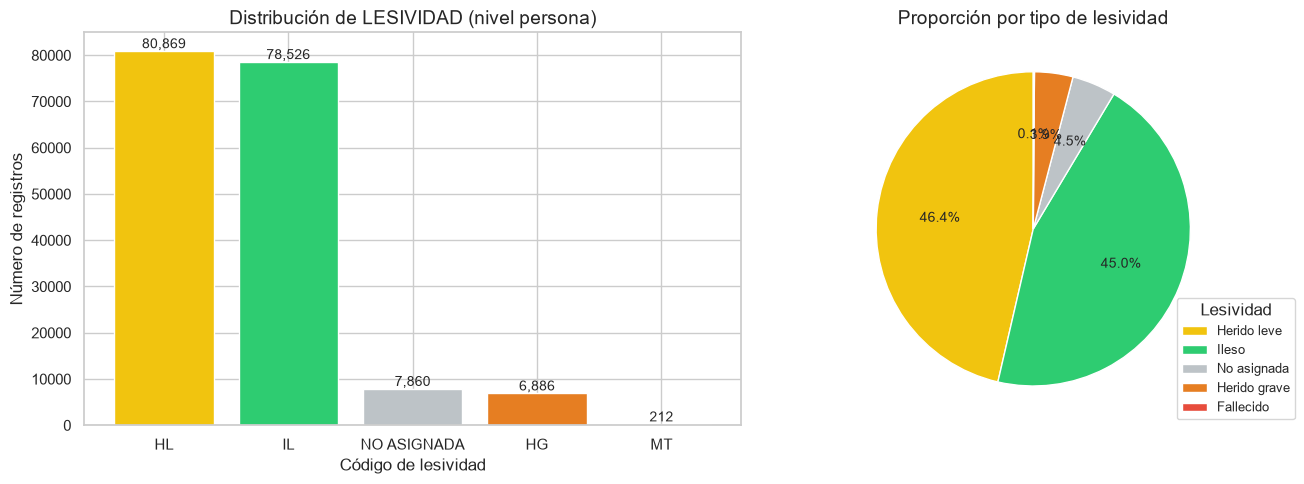

In [24]:
# Gráfico de distribución de LESIVIDAD
colores_lesividad_ext = {**COLORES_LESIVIDAD, 'NO ASIGNADA': '#bdc3c7'}
order = lesividad_dist.index.tolist()
colores_orden = [colores_lesividad_ext[c] for c in order]

labels_map = {'IL': 'Ileso', 'HL': 'Herido leve', 'HG': 'Herido grave',
              'MT': 'Fallecido', 'NO ASIGNADA': 'No asignada'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot
axes[0].bar(order, lesividad_dist.values, color=colores_orden, edgecolor='white')
axes[0].set_title('Distribución de LESIVIDAD (nivel persona)', fontsize=14)
axes[0].set_xlabel('Código de lesividad')
axes[0].set_ylabel('Número de registros')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Pie chart
labels_pie = [labels_map[c] for c in order]
wedges, _, _ = axes[1].pie(lesividad_dist.values, labels=None, autopct='%1.1f%%',
                            colors=colores_orden, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporción por tipo de lesividad', fontsize=14)
axes[1].legend(wedges, labels_pie, title='Lesividad', loc='lower left',
               bbox_to_anchor=(0.85, 0), fontsize=9)

plt.tight_layout()
plt.savefig('../figures/01_distribucion_lesividad.png', dpi=150)
plt.show()

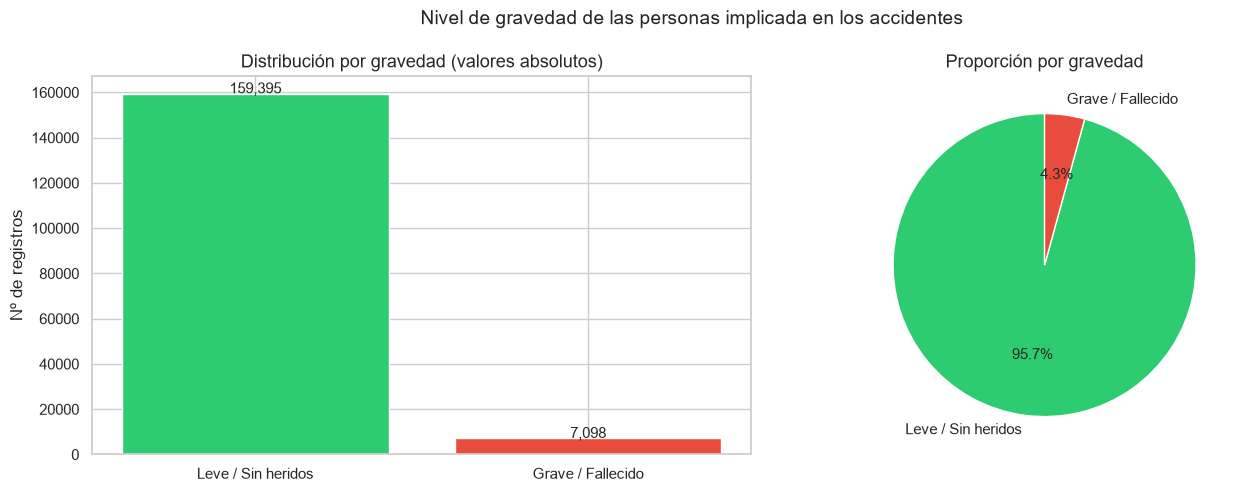

Desequilibrio de clases — ratio: 22.5:1
Graves + Fallecidos: 7,098 (4.3%)


In [26]:
# Clasificación binaria: Leve/Sin heridos vs Grave/Fallecido
gravedad_counts = df_sin_na['GRAVE'].map({0: 'Leve / Sin heridos', 1: 'Grave / Fallecido'}).value_counts()
ratio = gravedad_counts.max() / gravedad_counts.min()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_grav = ['#2ecc71', '#e74c3c']

axes[0].bar(gravedad_counts.index, gravedad_counts.values, color=colors_grav, edgecolor='white')
axes[0].set_title('Distribución por gravedad (valores absolutos)', fontsize=13)
axes[0].set_ylabel('Nº de registros')
for bar, val in zip(axes[0].patches, gravedad_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=11)

axes[1].pie(gravedad_counts.values, labels=gravedad_counts.index,
            autopct='%1.1f%%', colors=colors_grav, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporción por gravedad', fontsize=13)

plt.suptitle('Nivel de gravedad de las personas implicada en los accidentes', fontsize=14)
plt.tight_layout()
plt.savefig('../figures/01b_gravedad_binaria.png', dpi=150)
plt.show()

print(f'Desequilibrio de clases — ratio: {ratio:.1f}:1')
print(f'Graves + Fallecidos: {gravedad_counts.get("Grave / Fallecido", 0):,} ({gravedad_counts.get("Grave / Fallecido", 0)/gravedad_counts.sum()*100:.1f}%)')

### 📝 Resumen — Sección 2

> - La categoría más frecuente es HL (herido leve) con 80.869 registros (46,4%), seguida de IL (ileso) con 78.526 (45%).
> - Se excluyen 7.860 registros con `LESIVIDAD = 'NO ASIGNADA'` (4,51%) del análisis de la variable objetivo.
> - Las personas con heridas graves o fallecidas representan el **4,3% del total**, lo que supone un notable **desequilibrio de clases** (ratio ~22:1) que deberá abordarse en la fase de modelización.
> - Se utilizará **clasificación binaria**: Accidente grave/Accidente leve, ya que el objetivo es predecir la probabilidad de consecuencias graves dadas las condiciones del accidente.

---
## 3. Análisis temporal

El tiempo es una variable fundamental en la accidentalidad vial. En esta sección se analiza la distribución de accidentes por año, mes, día de la semana y franja horaria. Se añade un mapa de calor que combina hora y día para identificar los momentos de mayor riesgo, y una serie temporal para detectar tendencias y estacionalidad.

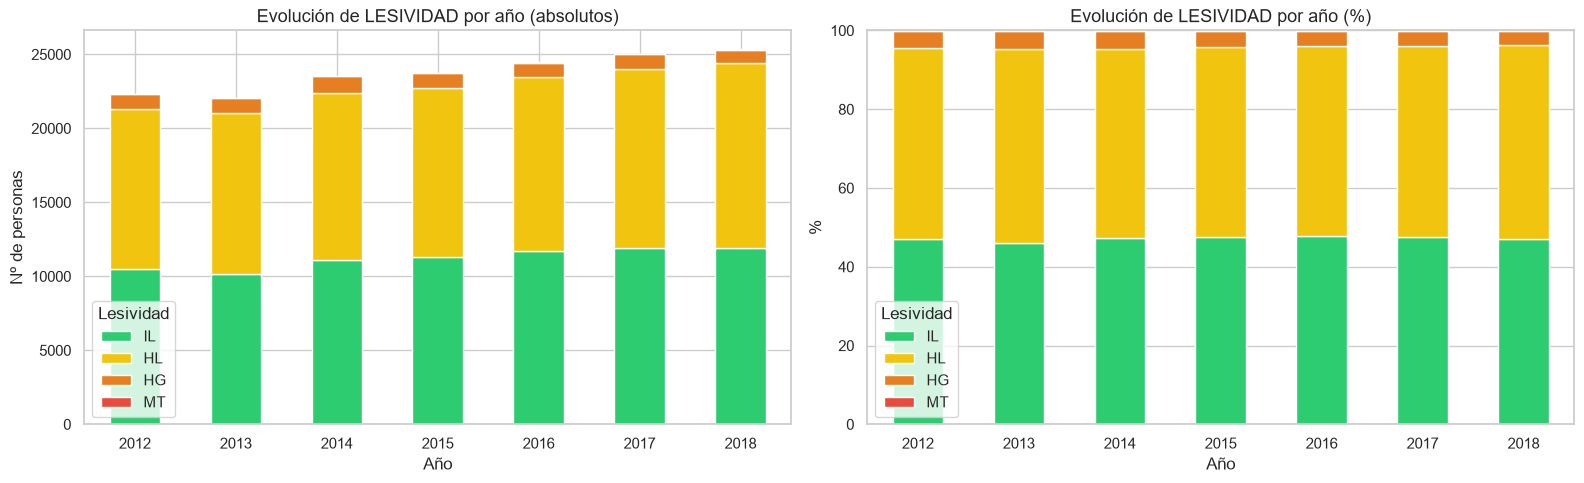

In [28]:
# Evolución de la gravedad por año
lesividad_año = (df_sin_na.groupby(['AÑO', 'LESIVIDAD'])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_año.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('Evolución de LESIVIDAD por año (absolutos)', fontsize=13)
axes[0].set_xlabel('Año'); axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad'); axes[0].tick_params(axis='x', rotation=0)

lesividad_año_pct = lesividad_año.div(lesividad_año.sum(axis=1), axis=0) * 100
lesividad_año_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('Evolución de LESIVIDAD por año (%)', fontsize=13)
axes[1].set_xlabel('Año'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100); axes[1].legend(title='Lesividad'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/01c_lesividad_por_año.png', dpi=150)
plt.show()

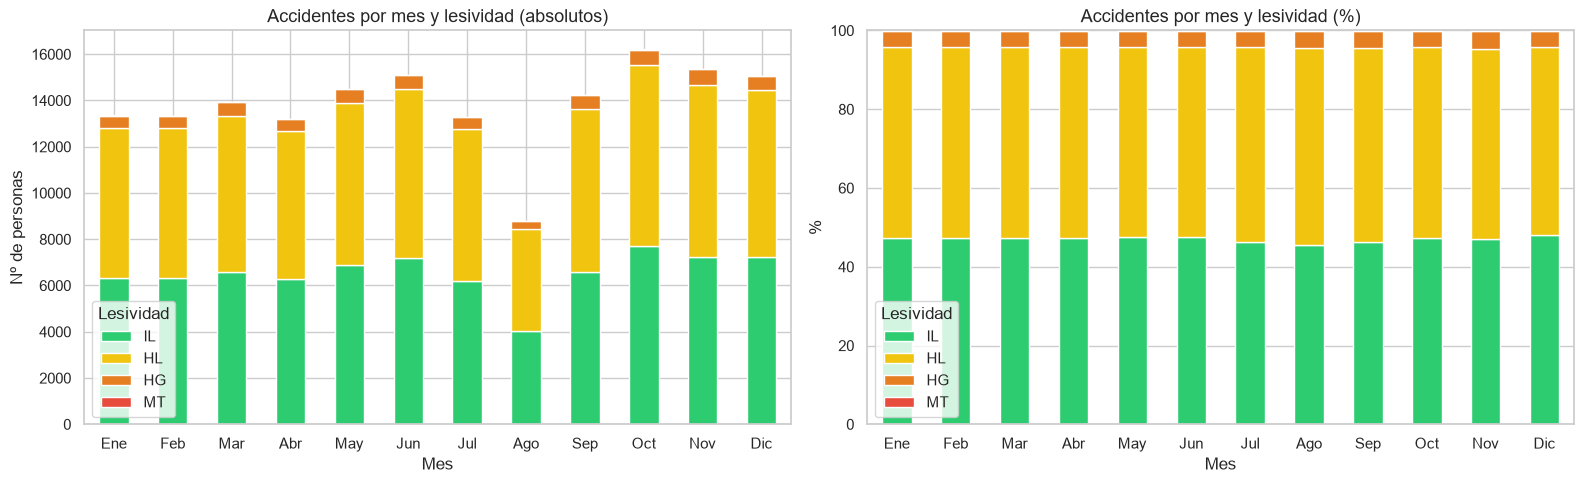

In [29]:
# Accidentes por mes con lesividad apilada
meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
          7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

lesividad_mes = (df_sin_na.groupby(['MES', 'LESIVIDAD'])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_mes.index = lesividad_mes.index.map(meses)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_mes.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('Accidentes por mes y lesividad (absolutos)', fontsize=13)
axes[0].set_xlabel('Mes'); axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad'); axes[0].tick_params(axis='x', rotation=0)

lesividad_mes_pct = lesividad_mes.div(lesividad_mes.sum(axis=1), axis=0) * 100
lesividad_mes_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('Accidentes por mes y lesividad (%)', fontsize=13)
axes[1].set_xlabel('Mes'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100); axes[1].legend(title='Lesividad'); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/03_accidentes_por_mes.png', dpi=150)
plt.show()

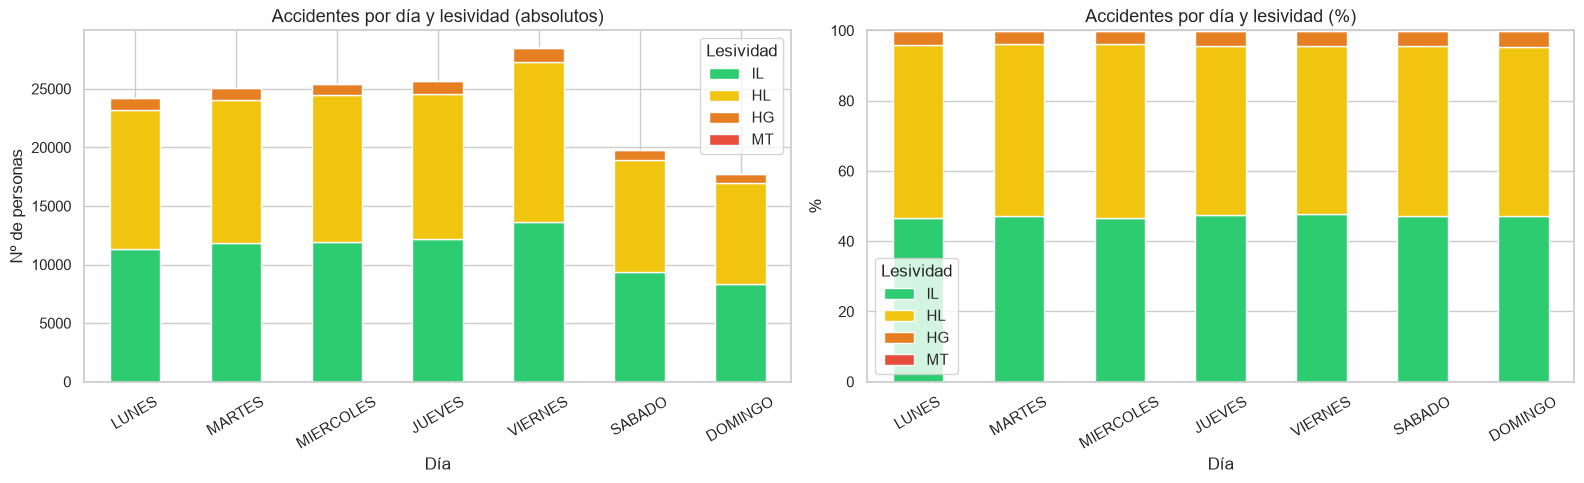

In [32]:
# Accidentes por día de la semana con lesividad apilada
orden_dias = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']

lesividad_dia = (df_sin_na.groupby(['DIA SEMANA', 'LESIVIDAD'])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(index=orden_dias, columns=ORDEN_LESIVIDAD, fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

lesividad_dia.plot(kind='bar', stacked=True, ax=axes[0],
                   color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('Accidentes por día y lesividad (absolutos)', fontsize=13)
axes[0].set_xlabel('Día'); axes[0].set_ylabel('Nº de personas')
axes[0].legend(title='Lesividad'); axes[0].tick_params(axis='x', rotation=30)

lesividad_dia_pct = lesividad_dia.div(lesividad_dia.sum(axis=1), axis=0) * 100
lesividad_dia_pct.plot(kind='bar', stacked=True, ax=axes[1],
                       color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('Accidentes por día y lesividad (%)', fontsize=13)
axes[1].set_xlabel('Día'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100); axes[1].legend(title='Lesividad'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/04_accidentes_por_dia.png', dpi=150)
plt.show()

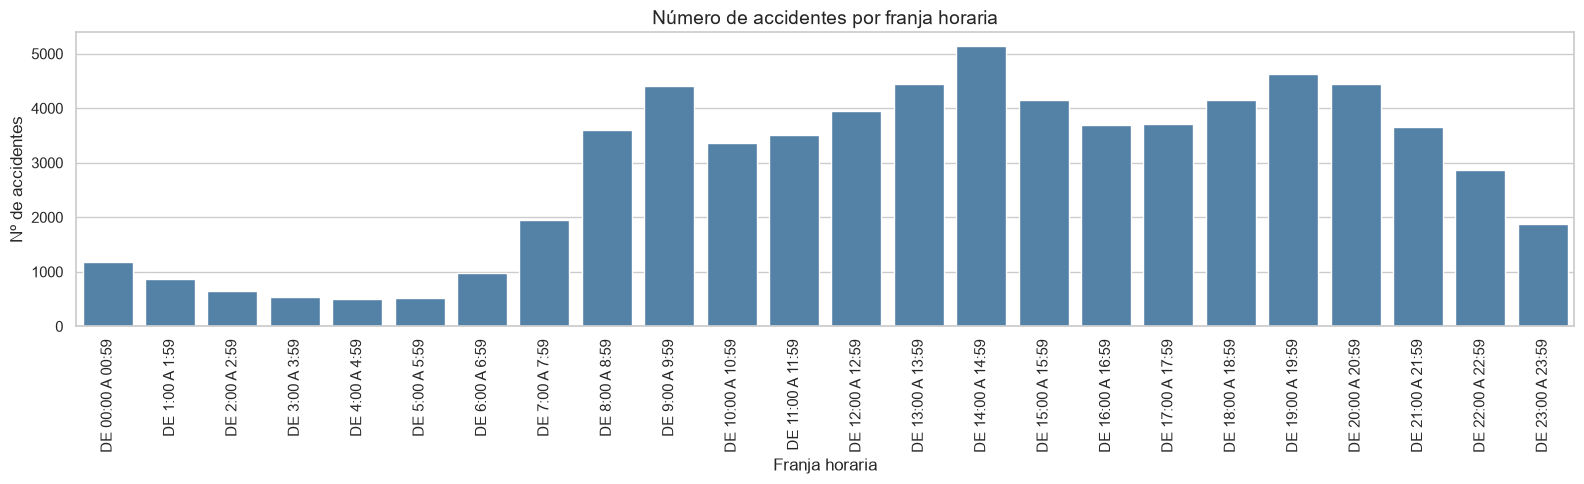

   RANGO HORARIO  Accidentes  Porcentaje (%)
DE 00:00 A 00:59        1176            1.71
  DE 1:00 A 1:59         872            1.27
  DE 2:00 A 2:59         654            0.95
  DE 3:00 A 3:59         537            0.78
  DE 4:00 A 4:59         501            0.73
  DE 5:00 A 5:59         520            0.76
  DE 6:00 A 6:59         985            1.43
  DE 7:00 A 7:59        1956            2.84
  DE 8:00 A 8:59        3600            5.23
  DE 9:00 A 9:59        4405            6.41
DE 10:00 A 10:59        3366            4.89
DE 11:00 A 11:59        3502            5.09
DE 12:00 A 12:59        3943            5.73
DE 13:00 A 13:59        4438            6.45
DE 14:00 A 14:59        5133            7.46
DE 15:00 A 15:59        4144            6.03
DE 16:00 A 16:59        3693            5.37
DE 17:00 A 17:59        3714            5.40
DE 18:00 A 18:59        4151            6.04
DE 19:00 A 19:59        4631            6.73
DE 20:00 A 20:59        4451            6.47
DE 21:00 A

In [33]:
# Franja horaria — orden cronológico (nivel accidente)
df_acc = df.drop_duplicates('Nº PARTE').copy()
df_acc['HORA'] = df_acc['RANGO HORARIO'].str.extract(r'(\d+)').astype(int)

accidentes_hora = (df_acc.groupby(['HORA', 'RANGO HORARIO']).size()
                         .reset_index(name='Accidentes')
                         .sort_values('HORA'))
accidentes_hora['Porcentaje (%)'] = (accidentes_hora['Accidentes'] / accidentes_hora['Accidentes'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(16, 5))
sns.barplot(data=accidentes_hora, x='RANGO HORARIO', y='Accidentes', ax=ax,
            order=accidentes_hora['RANGO HORARIO'], color='steelblue')
ax.set_title('Número de accidentes por franja horaria', fontsize=14)
ax.set_xlabel('Franja horaria'); ax.set_ylabel('Nº de accidentes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../figures/05_accidentes_por_hora.png', dpi=150)
plt.show()

print(accidentes_hora[['RANGO HORARIO', 'Accidentes', 'Porcentaje (%)']].to_string(index=False))

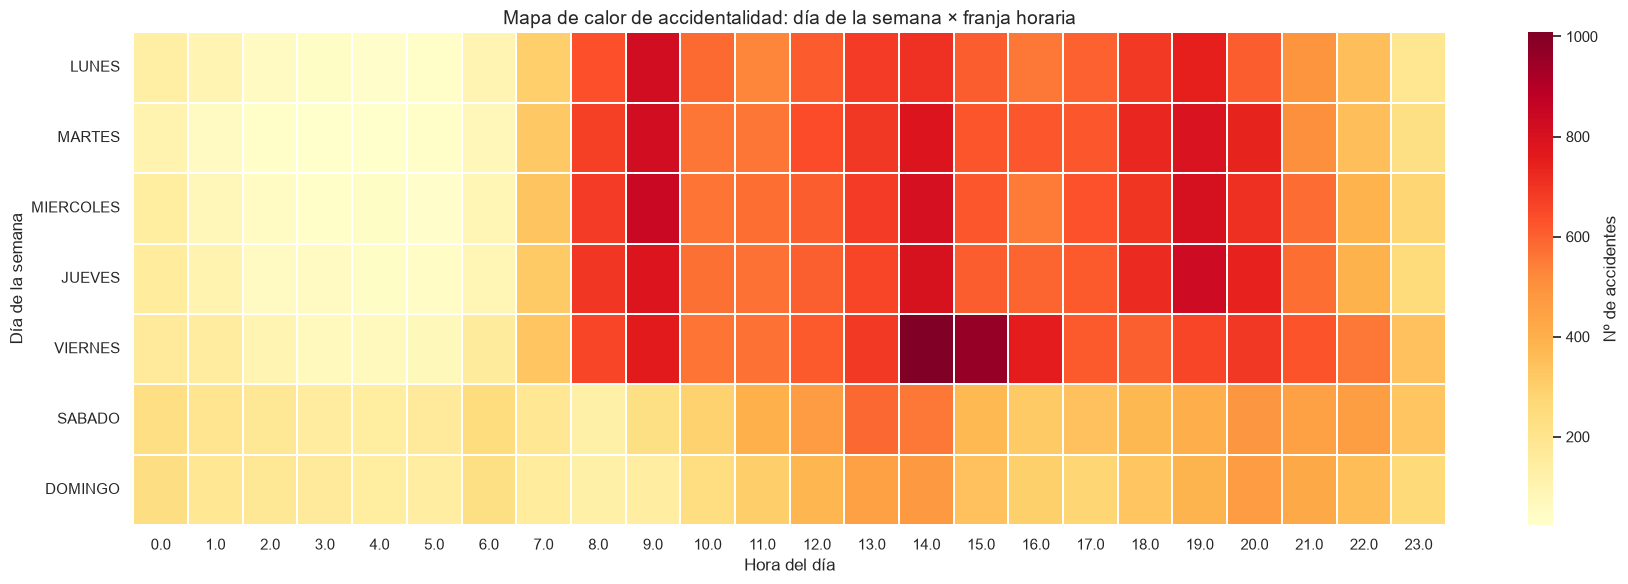

In [35]:
# Mapa de calor: hora × día de la semana (nivel accidente)
df_acc['HORA_NUM'] = df_acc['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)

heatmap_data = (df_acc.groupby(['DIA SEMANA', 'HORA_NUM'])
                      .size()
                      .unstack(fill_value=0)
                      .reindex(orden_dias, fill_value=0))

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Nº de accidentes'})
ax.set_title('Mapa de calor de accidentalidad: día de la semana × franja horaria', fontsize=14)
ax.set_xlabel('Hora del día'); ax.set_ylabel('Día de la semana')
plt.tight_layout()
plt.savefig('../figures/05b_heatmap_dia_hora.png', dpi=150)
plt.show()

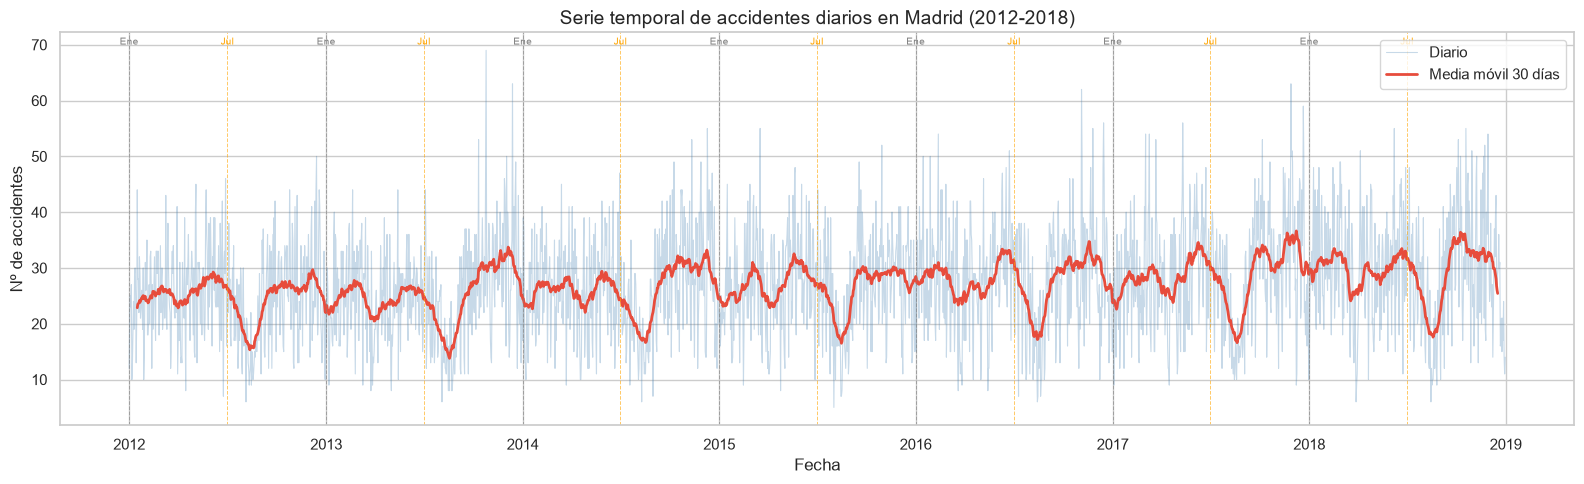

In [36]:
# Serie temporal: accidentes diarios con media móvil de 30 días
serie_temporal = (df_acc.groupby('FECHA').size().reset_index(name='Accidentes'))
serie_temporal['Media_30d'] = serie_temporal['Accidentes'].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(serie_temporal['FECHA'], serie_temporal['Accidentes'],
        color='steelblue', alpha=0.3, linewidth=0.8, label='Diario')
ax.plot(serie_temporal['FECHA'], serie_temporal['Media_30d'],
        color='#e74c3c', linewidth=2, label='Media móvil 30 días')

for year in range(2012, 2019):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.axvline(pd.Timestamp(f'{year}-07-01'), color='orange', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.text(pd.Timestamp(f'{year}-01-01'), ax.get_ylim()[1]*0.97, 'Ene', fontsize=7, color='gray', ha='center')
    ax.text(pd.Timestamp(f'{year}-07-01'), ax.get_ylim()[1]*0.97, 'Jul', fontsize=7, color='orange', ha='center')

ax.set_title('Serie temporal de accidentes diarios en Madrid (2012-2018)', fontsize=14)
ax.set_xlabel('Fecha'); ax.set_ylabel('Nº de accidentes')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/05c_serie_temporal.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 3

> - Aunque el número de accidentes registrados va en aumento a lo largo de los años, la **proporción entre las diferentes clases de lesividad se mantiene estable**, lo que sugiere que la gravedad relativa no ha variado estructuralmente entre 2012 y 2018.
> - Los meses con mayor accidentalidad son **octubre, noviembre y junio**. Julio y agosto presentan la menor siniestralidad, probablemente por la reducción del tráfico en período vacacional.
> - Los días laborables concentran más accidentes que el fin de semana, coincidiendo con los desplazamientos al trabajo.
> - Las franjas horarias de mayor riesgo son las **horas punta** (9h, 14h, 17h). El heatmap confirma la concentración de accidentes en días laborables en esas franjas y destaca la alta siniestralidad del **viernes entre las 14h y las 16h**.
> - La serie temporal muestra una tendencia estructuralmente estable (entre 20 y 35 accidentes/día) con una **estacionalidad anual clara**: caída en verano y repunte en otoño.

---
## 4. Análisis geográfico

El distrito donde ocurre el accidente puede estar relacionado con factores estructurales como la densidad de tráfico, el tipo de vías o la velocidad permitida. Se analiza tanto el volumen de accidentes como la tasa por habitante para una comparación más justa entre distritos.

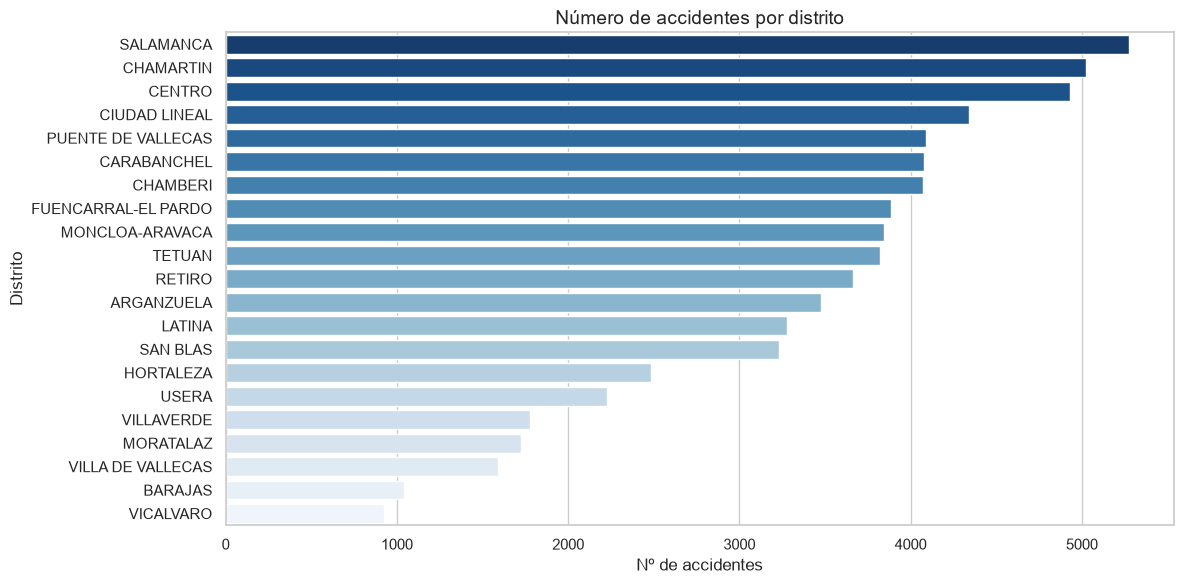

In [37]:
# Accidentes por distrito (nivel accidente)
accidentes_distrito = (df_acc.groupby('DISTRITO').size()
                             .sort_values(ascending=False)
                             .reset_index(name='Accidentes'))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=accidentes_distrito, x='Accidentes', y='DISTRITO', ax=ax, palette='Blues_r')
ax.set_title('Número de accidentes por distrito', fontsize=14)
ax.set_xlabel('Nº de accidentes'); ax.set_ylabel('Distrito')
plt.tight_layout()
plt.savefig('../figures/06_accidentes_por_distrito.png', dpi=150)
plt.show()

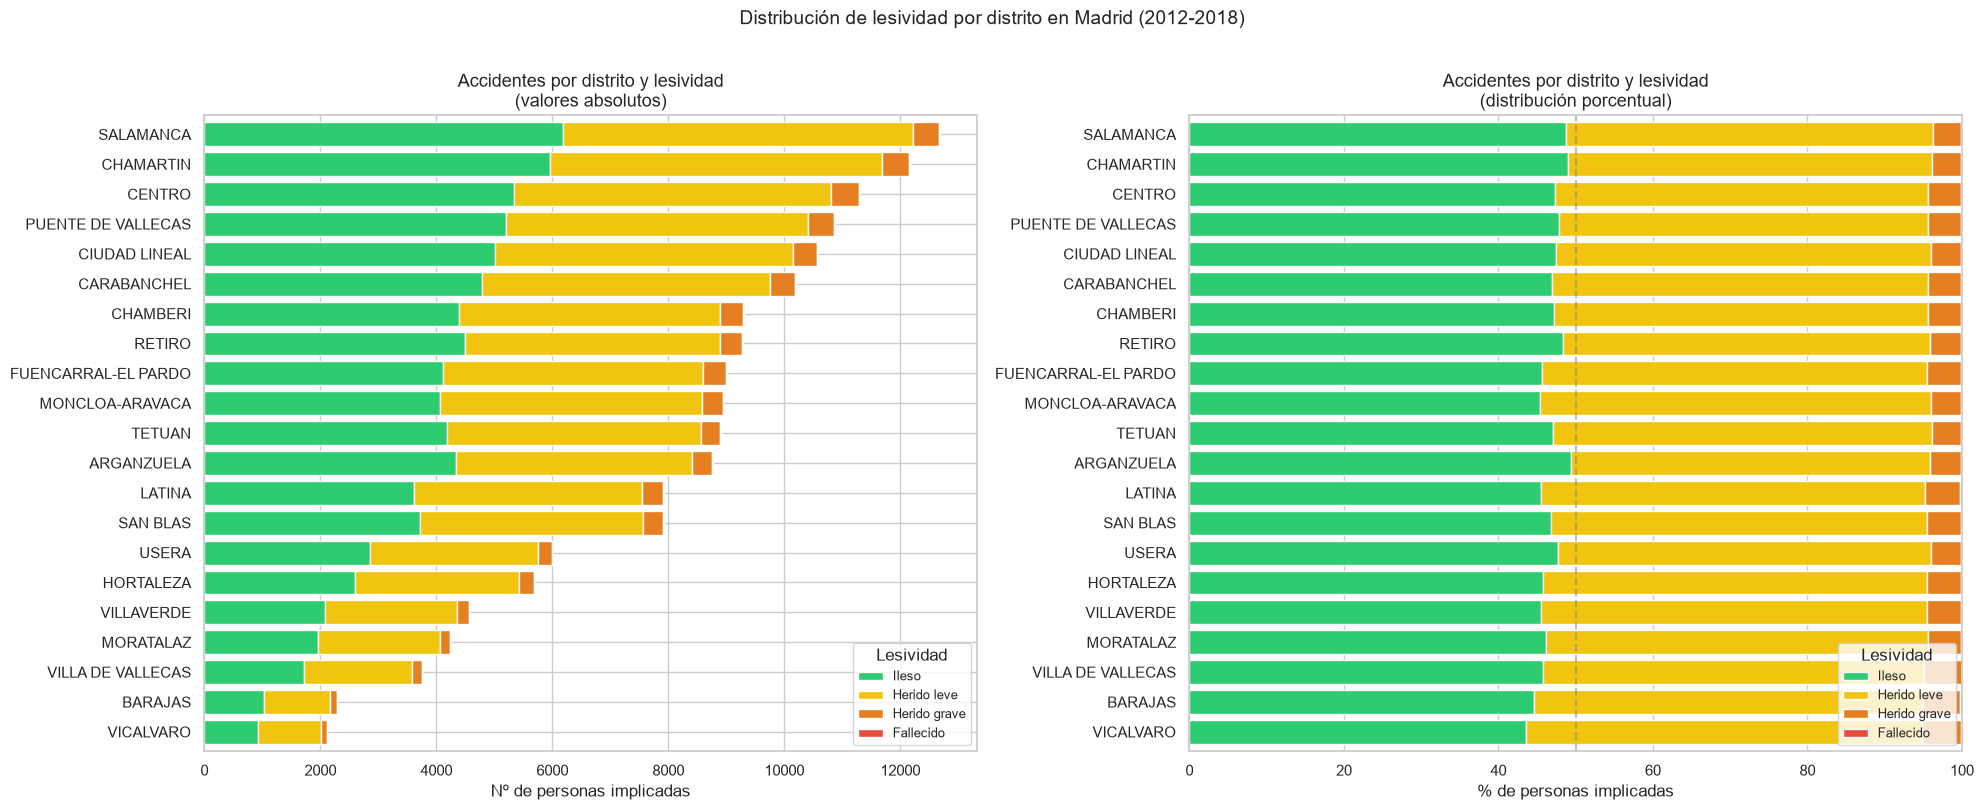

In [58]:
# Lesividad apilada por distrito
lesividad_distrito = (df_sin_na.groupby(['DISTRITO', 'LESIVIDAD'])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_distrito['TOTAL'] = lesividad_distrito.sum(axis=1)
lesividad_distrito = lesividad_distrito.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_pct_dist = lesividad_distrito.div(lesividad_distrito.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

lesividad_distrito.plot(kind='barh', stacked=True, ax=axes[0],
                        color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], width=0.8)
axes[0].set_title('Accidentes por distrito y lesividad\n(valores absolutos)', fontsize=13)
axes[0].set_xlabel('Nº de personas implicadas'); axes[0].set_ylabel('')
axes[0].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               loc='lower right', fontsize=9)

lesividad_pct_dist.plot(kind='barh', stacked=True, ax=axes[1],
                         color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], width=0.8)
axes[1].set_title('Accidentes por distrito y lesividad\n(distribución porcentual)', fontsize=13)
axes[1].set_xlabel('% de personas implicadas'); axes[1].set_ylabel('')
axes[1].set_xlim(0, 100)
axes[1].axvline(x=50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               loc='lower right', fontsize=9)

plt.suptitle('Distribución de lesividad por distrito en Madrid (2012-2018)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/06e_lesividad_por_distrito.png', dpi=150, bbox_inches='tight')
plt.show()

A continuación, se estudia si el número de accidentes tiene relación con la población media por distrito en Madrid durante el periodo estudiado.

In [40]:
# Población media por distrito (media aritmética 2012-2018)
# Fuente: Ayuntamiento de Madrid - Estadística padronal municipal
# Documento disponible en data/raw/poblacion_distritos_madrid.pdf
poblacion_distritos = {
    'CENTRO': 134379, 'ARGANZUELA': 152309, 'RETIRO': 119387,
    'SALAMANCA': 145977, 'CHAMARTIN': 143899, 'TETUAN': 154592,
    'CHAMBERI': 138938, 'FUENCARRAL-EL PARDO': 238485, 'MONCLOA-ARAVACA': 116626,
    'LATINA': 233353, 'CARABANCHEL': 243663, 'USERA': 136491,
    'PUENTE DE VALLECAS': 229315, 'MORATALAZ': 94598, 'CIUDAD LINEAL': 213941,
    'HORTALEZA': 174369, 'VILLAVERDE': 144534, 'VILLA DE VALLECAS': 101411,
    'VICALVARO': 68875, 'SAN BLAS': 156145, 'BARAJAS': 46918
}
N_AÑOS = 7

accidentes_distrito['Poblacion']        = accidentes_distrito['DISTRITO'].map(poblacion_distritos)
accidentes_distrito['Accidentes_anuales'] = accidentes_distrito['Accidentes'] / N_AÑOS
accidentes_distrito['Tasa_por_100k']    = (accidentes_distrito['Accidentes_anuales'] /
                                            accidentes_distrito['Poblacion'] * 100_000).round(1)
accidentes_distrito = accidentes_distrito.sort_values('Tasa_por_100k', ascending=False)
print(accidentes_distrito[['DISTRITO', 'Accidentes', 'Poblacion', 'Tasa_por_100k']].to_string(index=False))

           DISTRITO  Accidentes  Poblacion  Tasa_por_100k
             CENTRO        4931     134379          524.2
          SALAMANCA        5274     145977          516.1
          CHAMARTIN        5022     143899          498.6
    MONCLOA-ARAVACA        3845     116626          471.0
             RETIRO        3665     119387          438.5
           CHAMBERI        4071     138938          418.6
             TETUAN        3820     154592          353.0
         ARGANZUELA        3476     152309          326.0
            BARAJAS        1043      46918          317.6
           SAN BLAS        3229     156145          295.4
      CIUDAD LINEAL        4341     213941          289.9
          MORATALAZ        1725      94598          260.5
 PUENTE DE VALLECAS        4091     229315          254.9
        CARABANCHEL        4079     243663          239.1
              USERA        2227     136491          233.1
FUENCARRAL-EL PARDO        3884     238485          232.7
  VILLA DE VAL

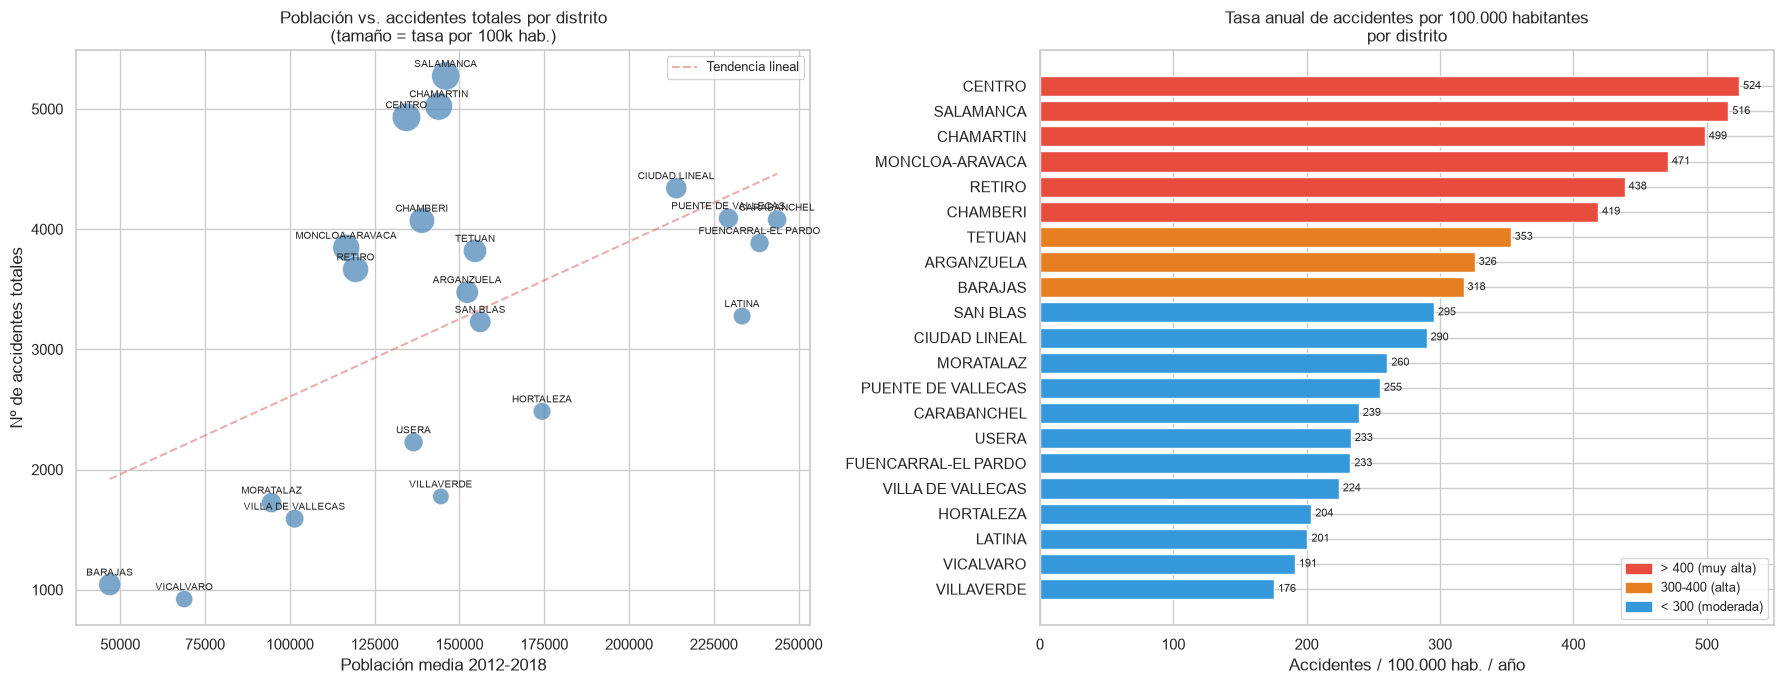

In [41]:
# Scatter: población vs accidentes + ranking por tasa
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.scatter(accidentes_distrito['Poblacion'], accidentes_distrito['Accidentes'],
           s=accidentes_distrito['Tasa_por_100k'] * 0.8,
           alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
for _, row in accidentes_distrito.iterrows():
    ax.annotate(row['DISTRITO'], (row['Poblacion'], row['Accidentes']),
                fontsize=7, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')
z = np.polyfit(accidentes_distrito['Poblacion'], accidentes_distrito['Accidentes'], 1)
p = np.poly1d(z)
x_line = np.linspace(accidentes_distrito['Poblacion'].min(), accidentes_distrito['Poblacion'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', alpha=0.5, label='Tendencia lineal')
ax.set_title('Población vs. accidentes totales por distrito\n(tamaño = tasa por 100k hab.)', fontsize=12)
ax.set_xlabel('Población media 2012-2018'); ax.set_ylabel('Nº de accidentes totales')
ax.legend(fontsize=9)

ax2 = axes[1]
datos_ordenados = accidentes_distrito.sort_values('Tasa_por_100k', ascending=True)
colores_tasa = ['#e74c3c' if t > 400 else '#e67e22' if t > 300 else '#3498db'
                for t in datos_ordenados['Tasa_por_100k']]
bars = ax2.barh(datos_ordenados['DISTRITO'], datos_ordenados['Tasa_por_100k'], color=colores_tasa)
ax2.set_title('Tasa anual de accidentes por 100.000 habitantes\npor distrito', fontsize=12)
ax2.set_xlabel('Accidentes / 100.000 hab. / año')
for bar, val in zip(bars, datos_ordenados['Tasa_por_100k']):
    ax2.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=8)
from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label='> 400 (muy alta)'),
           Patch(color='#e67e22', label='300-400 (alta)'),
           Patch(color='#3498db', label='< 300 (moderada)')]
ax2.legend(handles=leyenda, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('../figures/06c_scatter_poblacion_accidentes.png', dpi=150, bbox_inches='tight')
plt.show()

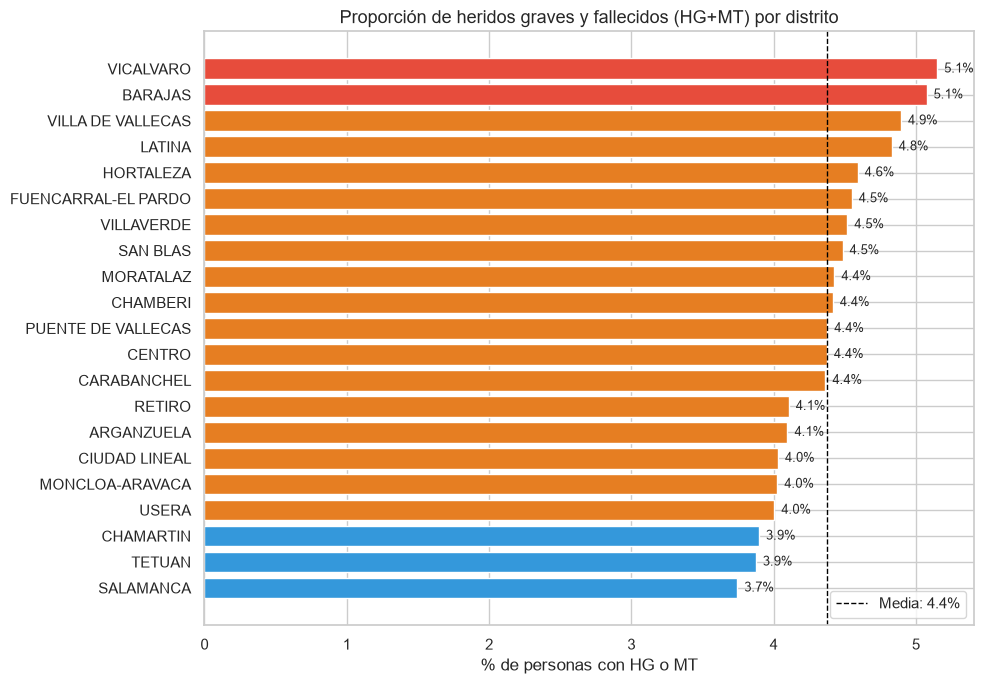

In [42]:
# Proporción de HG+MT por distrito
gravedad_distrito = (df_sin_na.groupby('DISTRITO')['GRAVE'].mean()
                               .mul(100).reset_index(name='Pct_HG_MT')
                               .sort_values('Pct_HG_MT', ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
colores = ['#e74c3c' if v > 5 else '#e67e22' if v > 4 else '#3498db'
           for v in gravedad_distrito['Pct_HG_MT']]
bars = ax.barh(gravedad_distrito['DISTRITO'], gravedad_distrito['Pct_HG_MT'], color=colores)
for bar, val in zip(bars, gravedad_distrito['Pct_HG_MT']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
media = gravedad_distrito['Pct_HG_MT'].mean()
ax.axvline(media, color='black', linestyle='--', linewidth=1, label=f'Media: {media:.1f}%')
ax.set_title('Proporción de heridos graves y fallecidos (HG+MT) por distrito', fontsize=13)
ax.set_xlabel('% de personas con HG o MT')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/06f_pct_graves_por_distrito.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 4

> - Una población más alta no se traduce directamente en más accidentes. **Salamanca, Chamartín y Centro** lideran en accidentalidad (tasa >490 accidentes/100k hab/año) sin ser los más poblados, lo que apunta al **tráfico de paso** como factor determinante.
> - Distritos periféricos con alta población (Latina, Carabanchel, Fuencarral) presentan tasas moderadas (<300).
> - Los distritos con mayor proporción de heridos graves o fallecidos (Villa de Vallecas, Vicálvaro, Barajas) **no coinciden** con los de mayor accidentalidad absoluta, lo que sugiere que el tipo de vía (carreteras de alta velocidad en periferia) influye más en la gravedad que el volumen.

---
## 5. Condiciones del accidente

En esta sección se analizan las variables relacionadas con el contexto en el que ocurrió el accidente: tipo de accidente, lugar del accidente, condiciones meteorológicas y estado del firme. Estas variables son candidatas clave para el modelo predictivo. Se analiza no solo su frecuencia, sino también su relación con la gravedad del accidente.

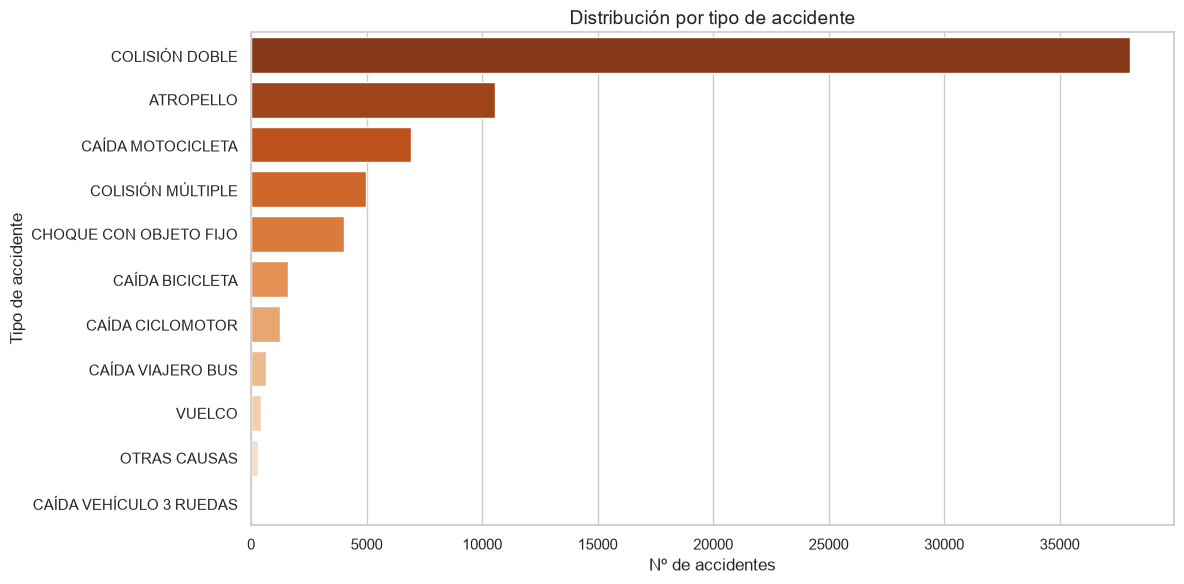

         TIPO ACCIDENTE  Accidentes  Porcentaje (%)
         COLISIÓN DOBLE       38047           55.32
              ATROPELLO       10564           15.36
      CAÍDA MOTOCICLETA        6907           10.04
      COLISIÓN MÚLTIPLE        4988            7.25
 CHOQUE CON OBJETO FIJO        4041            5.88
        CAÍDA BICICLETA        1583            2.30
       CAÍDA CICLOMOTOR        1272            1.85
      CAÍDA VIAJERO BUS         650            0.95
                 VUELCO         426            0.62
           OTRAS CAUSAS         289            0.42
CAÍDA VEHÍCULO 3 RUEDAS           6            0.01


In [43]:
# Tipo de accidente (nivel accidente)
tipo_accidente = (df_acc.groupby('TIPO ACCIDENTE').size()
                        .sort_values(ascending=False)
                        .reset_index(name='Accidentes'))
tipo_accidente['Porcentaje (%)'] = (tipo_accidente['Accidentes'] / tipo_accidente['Accidentes'].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=tipo_accidente, x='Accidentes', y='TIPO ACCIDENTE', ax=ax, palette='Oranges_r')
ax.set_title('Distribución por tipo de accidente', fontsize=14)
ax.set_xlabel('Nº de accidentes'); ax.set_ylabel('Tipo de accidente')
plt.tight_layout()
plt.savefig('../figures/07_tipo_accidente.png', dpi=150)
plt.show()
print(tipo_accidente.to_string(index=False))

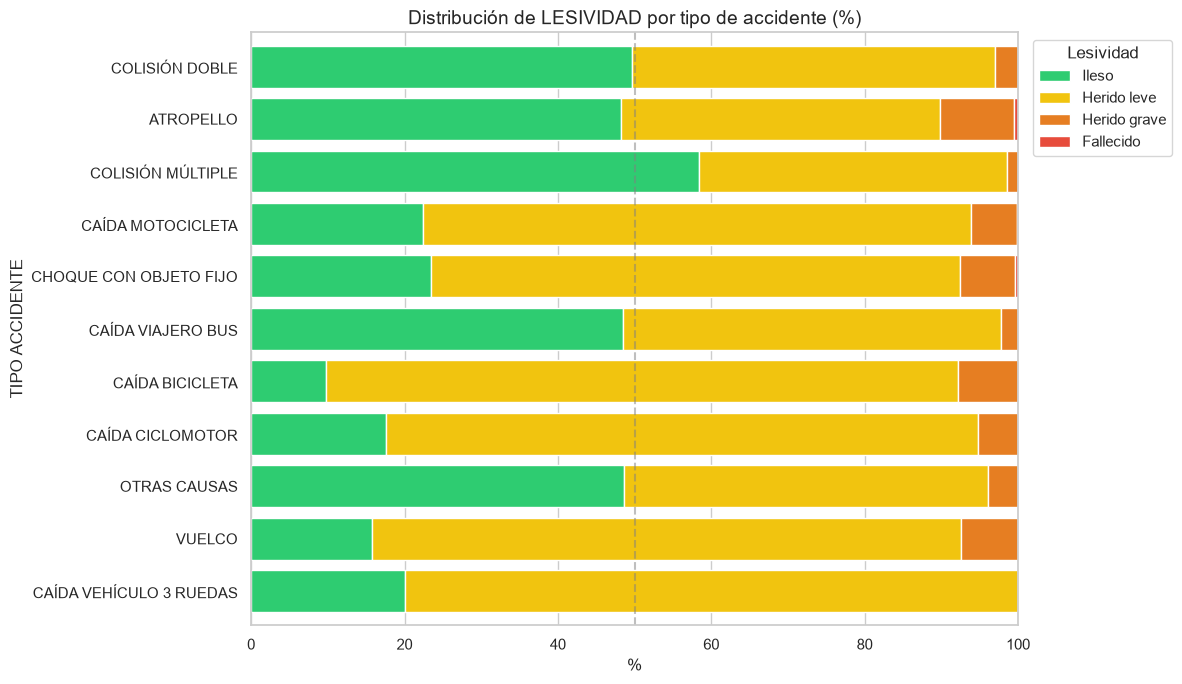

In [ ]:
# LESIVIDAD por tipo de accidente — ¿qué tipos son más graves?
lesividad_tipo_acc = (df_sin_na.groupby(['TIPO ACCIDENTE', 'LESIVIDAD'])
                               .size()
                               .unstack(fill_value=0)
                               .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_tipo_acc['TOTAL'] = lesividad_tipo_acc.sum(axis=1)
lesividad_tipo_acc = lesividad_tipo_acc.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_tipo_acc_pct = lesividad_tipo_acc.div(lesividad_tipo_acc.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
lesividad_tipo_acc_pct[ORDEN_LESIVIDAD].plot(kind='barh', stacked=True, ax=ax,
                             color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], width=0.8)
ax.set_title('Distribución de LESIVIDAD por tipo de accidente (%)', fontsize=14)
ax.set_xlabel('%'); ax.set_xlim(0, 100)
ax.axvline(50, color='grey', linestyle='--', alpha=0.5, )
ax.legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../figures/07b_lesividad_por_tipo_accidente.png', dpi=150, bbox_inches='tight')
plt.show()

### Lugar del accidente

Se analiza brevemente el tipo de lugar o vía en que se producen los accidentes y su relación con la gravedad.

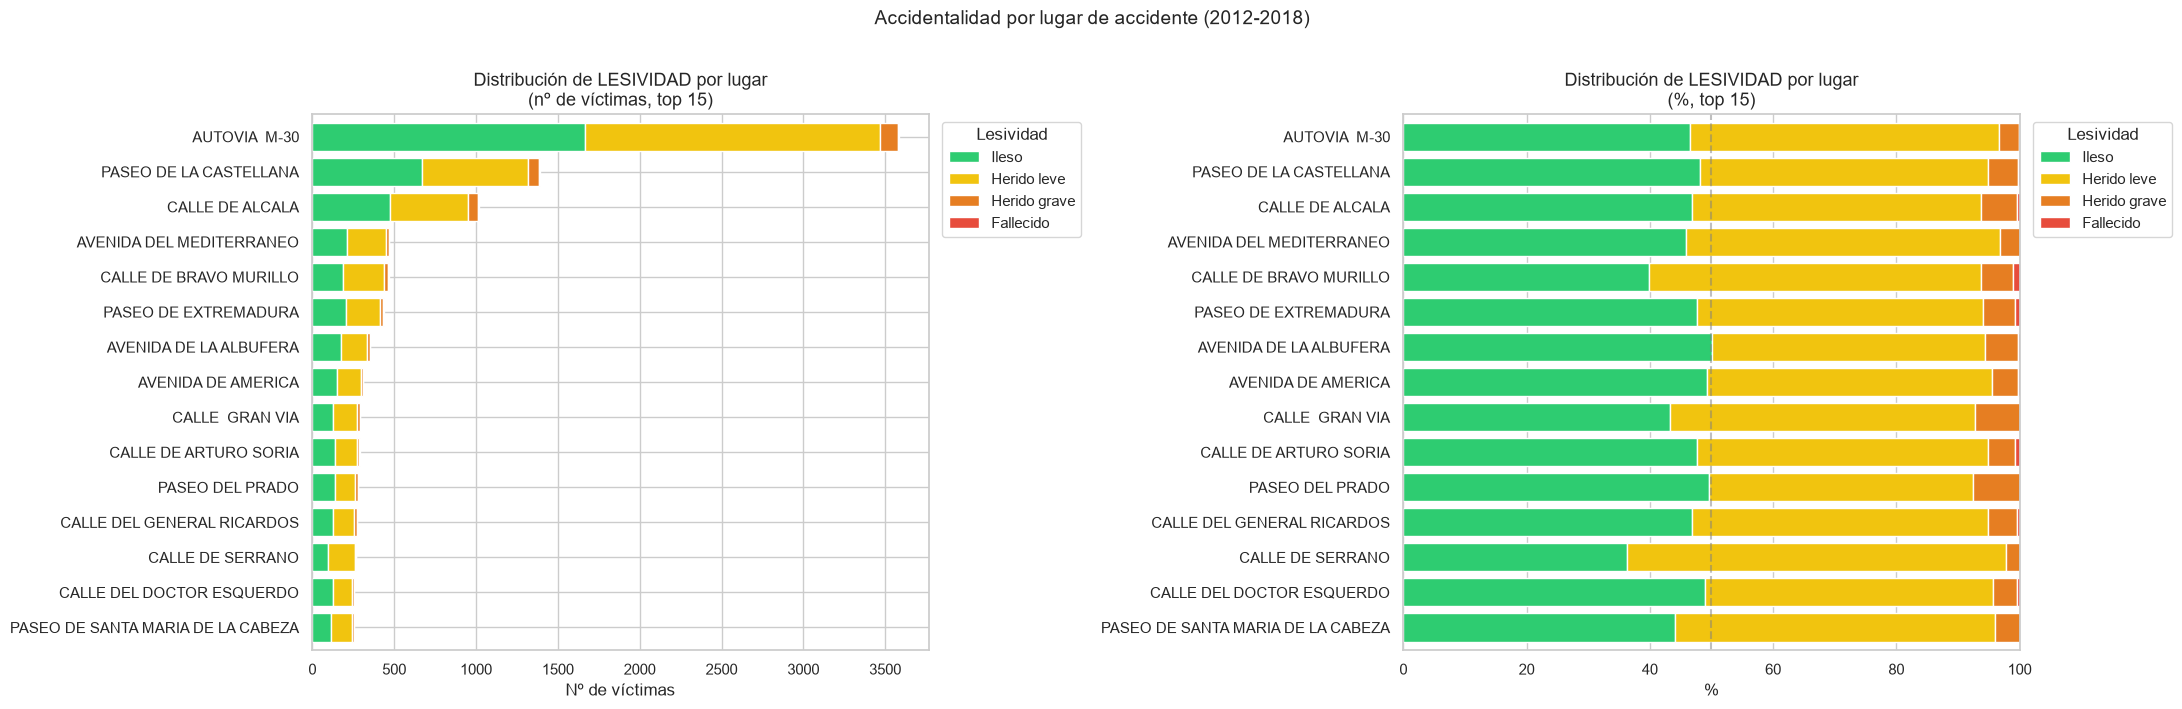

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Orden: top15 por n_accidentes, invertido para barh (mayor arriba)
orden = top15_lugares[::-1]

lesividad_lugar_ord = lesividad_lugar.reindex(orden)
lesividad_lugar_pct_ord = lesividad_lugar_pct.reindex(orden)

colores = [COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD]
labels  = ['Ileso', 'Herido leve', 'Herido grave', 'Fallecido']

# ── Izquierda: valores absolutos apilados 
lesividad_lugar_ord.plot(kind='barh', stacked=True, ax=axes[0],
                         color=colores, width=0.8)
axes[0].set_title('Distribución de LESIVIDAD por lugar\n(nº de víctimas, top 15)', fontsize=13)
axes[0].set_xlabel('Nº de víctimas')
axes[0].set_ylabel('')
axes[0].legend(title='Lesividad', labels=labels,
               bbox_to_anchor=(1.01, 1), loc='upper left')

# ── Derecha: distribución porcentual apilada 
lesividad_lugar_pct_ord.plot(kind='barh', stacked=True, ax=axes[1],
                              color=colores, width=0.8)
axes[1].set_title('Distribución de LESIVIDAD por lugar\n(%, top 15)', fontsize=13)
axes[1].set_xlabel('%')
axes[1].set_xlim(0, 100)
axes[1].axvline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].set_ylabel('')
axes[1].legend(title='Lesividad', labels=labels,
               bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Accidentalidad por lugar de accidente (2012-2018)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/07d_lugar_lesividad.png', dpi=150, bbox_inches='tight')
plt.show()

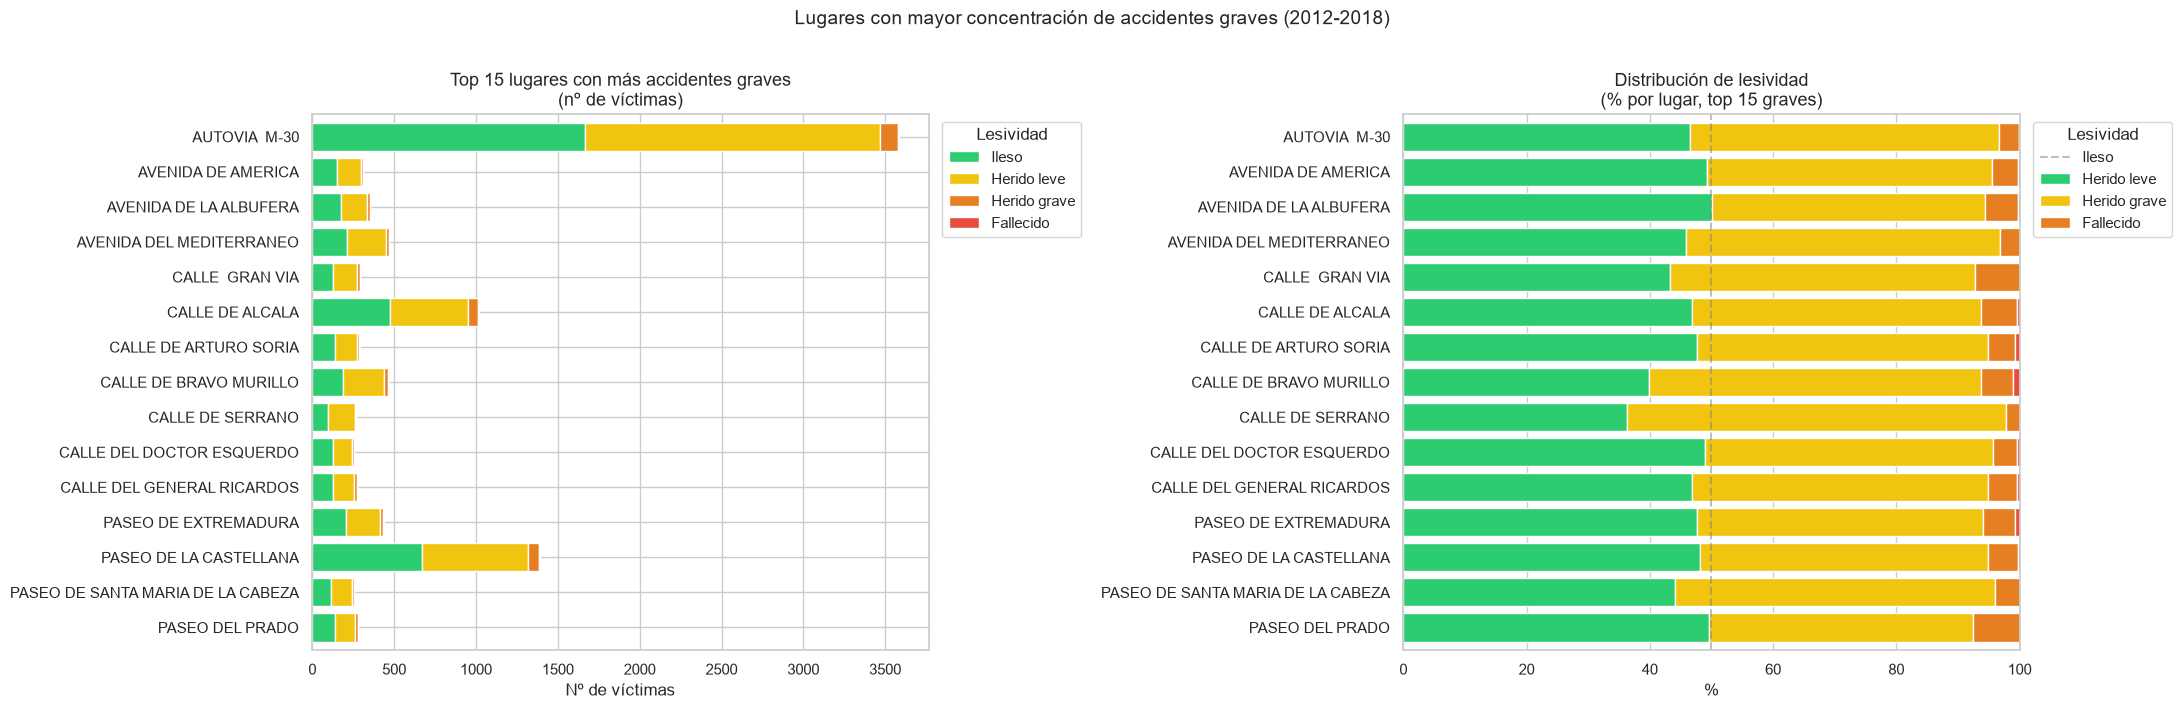

In [110]:
# ── Top 15 lugares por nº de accidentes graves (HG + fallecido) ───────────────
graves_cats = [c for c in ORDEN_LESIVIDAD if c in ['HERIDO GRAVE', 'FALLECIDO']]  # ajusta a tus valores exactos

lugar_graves = (lesividad_lugar[graves_cats]
                .sum(axis=1)
                .sort_values(ascending=False)
                .head(15))

top15_graves = lugar_graves.index.tolist()
orden_graves = top15_graves[::-1]  # invertir para barh (mayor arriba)

lesividad_graves_ord     = lesividad_lugar.reindex(orden_graves)
lesividad_graves_pct_ord = (lesividad_lugar.div(lesividad_lugar.sum(axis=1), axis=0) * 100
                            ).reindex(orden_graves)

# ── Figura ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

colores = [COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD]
labels  = ['Ileso', 'Herido leve', 'Herido grave', 'Fallecido']

# Izquierda: absolutos
lesividad_graves_ord.plot(kind='barh', stacked=True, ax=axes[0],
                          color=colores, width=0.8)
axes[0].set_title('Top 15 lugares con más accidentes graves\n(nº de víctimas)', fontsize=13)
axes[0].set_xlabel('Nº de víctimas')
axes[0].set_ylabel('')
axes[0].legend(title='Lesividad', labels=labels,
               bbox_to_anchor=(1.01, 1), loc='upper left')

# Derecha: proporción %
lesividad_graves_pct_ord.plot(kind='barh', stacked=True, ax=axes[1],
                               color=colores, width=0.8)
axes[1].set_title('Distribución de lesividad\n(% por lugar, top 15 graves)', fontsize=13)
axes[1].set_xlabel('%')
axes[1].set_xlim(0, 100)
axes[1].axvline(50, color='grey', linestyle='--', alpha=0.5)
axes[1].set_ylabel('')
axes[1].legend(title='Lesividad', labels=labels,
               bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle('Lugares con mayor concentración de accidentes graves (2012-2018)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../figures/07e_top15_graves.png', dpi=150, bbox_inches='tight')
plt.show()

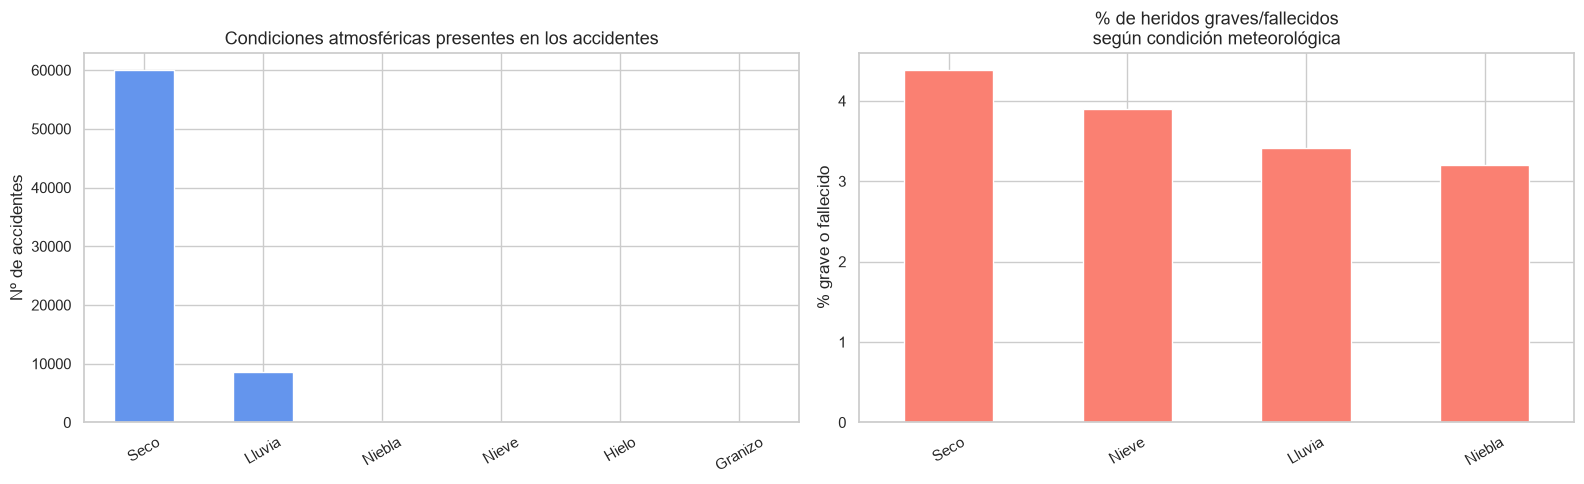

        Nº accidentes Porcentaje (%)  % graves
Granizo             9           0.01       NaN
Hielo              65           0.09       NaN
Lluvia           8535          12.41      3.41
Niebla            188           0.27      3.20
Nieve              68            0.1      3.90
Seco            59975          87.21      4.38


In [84]:
# Condiciones meteorológicas (CPFA) — frecuencia y tasa de gravedad
cols_cpfa = [c for c in df.columns if c.startswith('CPFA')]

cpfa_df   = df_acc[cols_cpfa].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cpfa_counts = cpfa_df.sum().sort_values(ascending=False)

tasas_graves_cpfa = {}
for col in cols_cpfa:
    nombre = col.replace('CPFA ', '')
    mask = df_sin_na[col].str.strip() == 'SI'
    if mask.sum() > 100:
        tasas_graves_cpfa[nombre] = df_sin_na.loc[mask, 'GRAVE'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cpfa_counts.plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title('Condiciones atmosféricas presentes en los accidentes', fontsize=13)
axes[0].set_xticklabels([c.replace('CPFA ', '') for c in cpfa_counts.index], rotation=30)
axes[0].set_ylabel('Nº de accidentes')

pd.Series(tasas_graves_cpfa).sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('% de heridos graves/fallecidos\nsegún condición meteorológica', fontsize=13)
axes[1].set_ylabel('% grave o fallecido'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/08_condiciones_atmosfericas.png', dpi=150)
plt.show()

tabla_cpfa = pd.DataFrame({
    'Nº accidentes': cpfa_counts,
    'Porcentaje (%)': (cpfa_counts / len(df_acc) * 100).round(2),
    '% graves':       pd.Series({f'CPFA {k}': v for k, v in tasas_graves_cpfa.items()}).round(2)
})
tabla_cpfa.index = [i.replace('CPFA ', '') for i in tabla_cpfa.index]
print(tabla_cpfa.to_string())

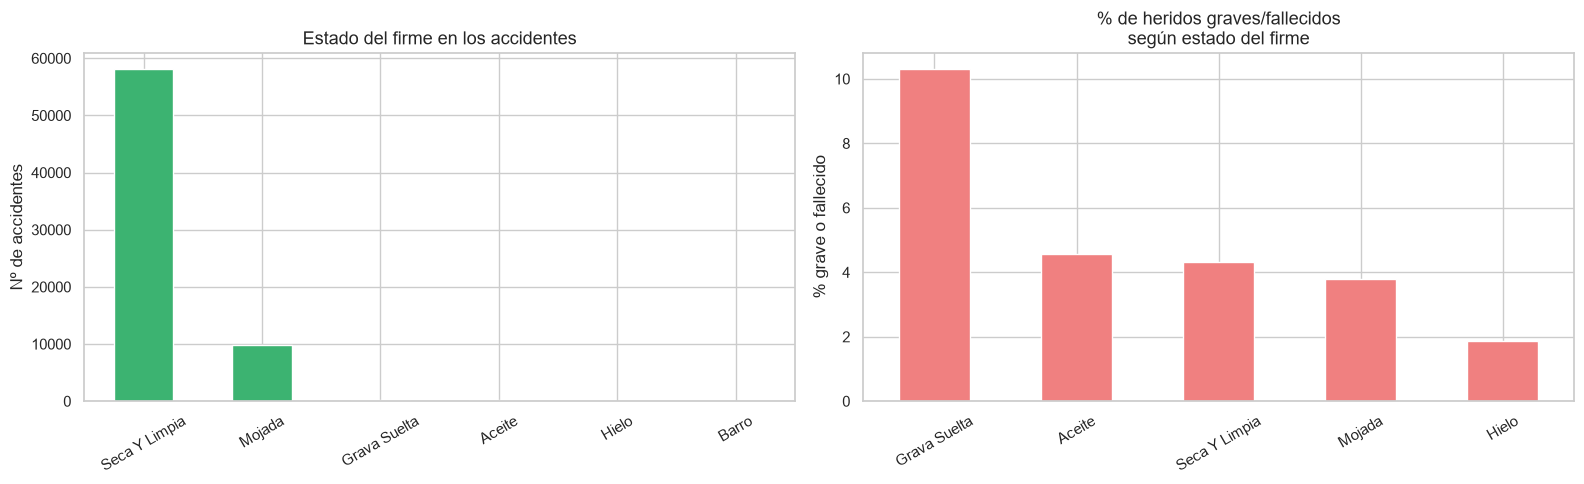

              Nº accidentes Porcentaje (%)  % graves
Aceite                  260           0.38      4.57
Barro                    59           0.09       NaN
Grava Suelta            273            0.4     10.30
Hielo                   102           0.15      1.85
Mojada                 9828          14.29      3.78
Seca Y Limpia         58073          84.44      4.32


In [85]:
# Estado del firme (CPSV) — frecuencia y tasa de gravedad
cols_cpsv = [c for c in df.columns if c.startswith('CPSV')]

cpsv_df     = df_acc[cols_cpsv].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cpsv_counts = cpsv_df.sum().sort_values(ascending=False)

tasas_graves_cpsv = {}
for col in cols_cpsv:
    nombre = col.replace('CPSV ', '')
    mask = df_sin_na[col].str.strip() == 'SI'
    if mask.sum() > 100:
        tasas_graves_cpsv[nombre] = df_sin_na.loc[mask, 'GRAVE'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cpsv_counts.plot(kind='bar', ax=axes[0], color='mediumseagreen')
axes[0].set_title('Estado del firme en los accidentes', fontsize=13)
axes[0].set_xticklabels([c.replace('CPSV ', '') for c in cpsv_counts.index], rotation=30)
axes[0].set_ylabel('Nº de accidentes')

pd.Series(tasas_graves_cpsv).sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('% de heridos graves/fallecidos\nsegún estado del firme', fontsize=13)
axes[1].set_ylabel('% grave o fallecido'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../figures/09_estado_firme.png', dpi=150)
plt.show()

tabla_cpsv = pd.DataFrame({
    'Nº accidentes': cpsv_counts,
    'Porcentaje (%)': (cpsv_counts / len(df_acc) * 100).round(2),
    '% graves':       pd.Series({f'CPSV {k}': v for k, v in tasas_graves_cpsv.items()}).round(2)
})
tabla_cpsv.index = [i.replace('CPSV ', '') for i in tabla_cpsv.index]
print(tabla_cpsv.to_string())

### 📝 Resumen — Sección 5

> - El tipo de accidente más frecuente es **colisión doble** (>50%), seguido de atropello y caída de motocicleta. Sin embargo, el tipo con mayor proporción de heridos graves es **caída de bicicleta**.
> - La condición meteorológica predominante es **seco**, coherente con el clima de Madrid. No obstante, la tasa de graves es significativamente mayor cuando nieva o llueve.
> - El estado del firme con mayor tasa de accidentes graves es **grava suelta y aceite en la vía**, aunque son situaciones poco frecuentes. La gran mayoría de accidentes ocurren en firme seco y limpio.
> - La variable `LUGAR ACCIDENTE` muestra que los accidentes más graves ocurren en vías de mayor velocidad, mientras que las intersecciones y cruces concentran el mayor volumen de accidentes.

---
## 6. Análisis univariante: Nº de víctimas por accidente

`Nº VICTIMAS *` es la única variable numérica del dataset. Recoge el número de víctimas (personas heridas, graves o fallecidas) asociadas a cada accidente. Se analiza su distribución, estadísticos descriptivos, presencia de outliers y relación con la variable objetivo.

> **Nota:** Este análisis se realiza a nivel accidente (una fila por `Nº PARTE`), ya que la variable toma el mismo valor para todos los implicados en un mismo accidente.

In [86]:
# Estadísticos descriptivos de Nº VICTIMAS *
victimas_serie = df_acc['Nº VICTIMAS *'].dropna()

desc = {
    'Recuento':            victimas_serie.count(),
    'Media':               victimas_serie.mean(),
    'Mediana':             victimas_serie.median(),
    'Moda':                victimas_serie.mode()[0],
    'Desviación estándar': victimas_serie.std(),
    'Varianza':            victimas_serie.var(),
    'Mínimo':              victimas_serie.min(),
    'Q1 (25%)':            victimas_serie.quantile(0.25),
    'Q3 (75%)':            victimas_serie.quantile(0.75),
    'IQR':                 victimas_serie.quantile(0.75) - victimas_serie.quantile(0.25),
    'Máximo':              victimas_serie.max(),
    'Asimetría (skewness)': victimas_serie.skew(),
    'Curtosis (kurtosis)': victimas_serie.kurtosis(),
}

for k, v in desc.items():
    print(f'{k:<28}: {v:.4f}' if isinstance(v, float) else f'{k:<28}: {v}')

# Límites de outliers (criterio IQR)
iqr = desc['IQR']
lim_inf = desc['Q1 (25%)'] - 1.5 * iqr
lim_sup = desc['Q3 (75%)'] + 1.5 * iqr
n_outliers = ((victimas_serie < lim_inf) | (victimas_serie > lim_sup)).sum()
print(f'\nLímite inferior outliers (IQR): {lim_inf:.2f}')
print(f'Límite superior outliers (IQR): {lim_sup:.2f}')
print(f'Accidentes con outliers:        {n_outliers:,} ({n_outliers/len(victimas_serie)*100:.2f}%)')

Recuento                    : 68773
Media                       : 1.2791
Mediana                     : 1.0000
Moda                        : 1
Desviación estándar         : 0.7213
Varianza                    : 0.5203
Mínimo                      : 1
Q1 (25%)                    : 1.0000
Q3 (75%)                    : 1.0000
IQR                         : 0.0000
Máximo                      : 19
Asimetría (skewness)        : 4.6835
Curtosis (kurtosis)         : 43.9921

Límite inferior outliers (IQR): 1.00
Límite superior outliers (IQR): 1.00
Accidentes con outliers:        13,035 (18.95%)


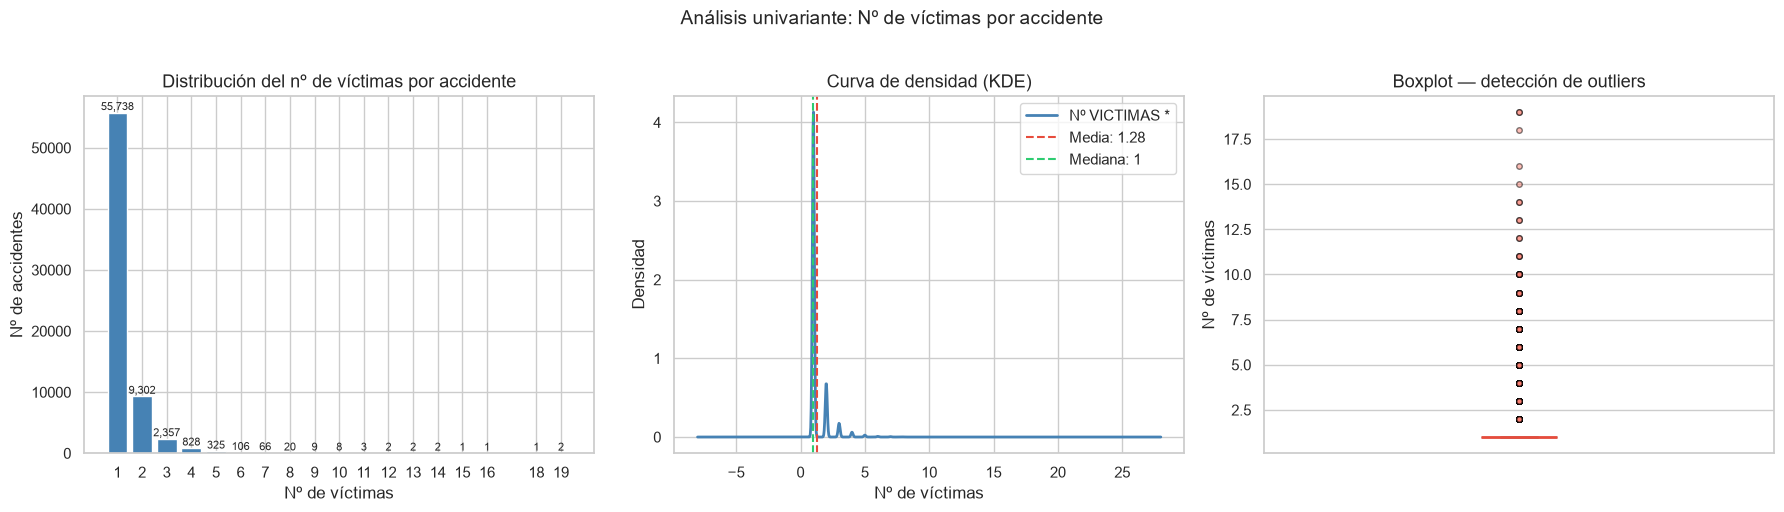

In [87]:
# Distribución de Nº VICTIMAS *: histograma, KDE y boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma con frecuencia absoluta
vc = victimas_serie.value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
for x, y in zip(vc.index, vc.values):
    axes[0].text(x, y + 50, f'{y:,}', ha='center', va='bottom', fontsize=8)
axes[0].set_title('Distribución del nº de víctimas por accidente', fontsize=13)
axes[0].set_xlabel('Nº de víctimas'); axes[0].set_ylabel('Nº de accidentes')
axes[0].set_xticks(vc.index)

# KDE (densidad de probabilidad)
victimas_serie.plot.kde(ax=axes[1], color='steelblue', linewidth=2)
axes[1].axvline(victimas_serie.mean(), color='#e74c3c', linestyle='--', label=f'Media: {victimas_serie.mean():.2f}')
axes[1].axvline(victimas_serie.median(), color='#2ecc71', linestyle='--', label=f'Mediana: {victimas_serie.median():.0f}')
axes[1].set_title('Curva de densidad (KDE)', fontsize=13)
axes[1].set_xlabel('Nº de víctimas'); axes[1].set_ylabel('Densidad')
axes[1].legend()

# Boxplot
axes[2].boxplot(victimas_serie, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='#e74c3c', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='salmon', markersize=4, alpha=0.5))
axes[2].set_title('Boxplot — detección de outliers', fontsize=13)
axes[2].set_ylabel('Nº de víctimas')
axes[2].set_xticks([])

plt.suptitle('Análisis univariante: Nº de víctimas por accidente', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/15_univariante_victimas.png', dpi=150, bbox_inches='tight')
plt.show()

In [89]:
from scipy.stats import kstest, norm as sp_norm

n_muestra = min(5000, len(victimas_serie))
muestra   = victimas_serie.sample(n_muestra, random_state=42)

# Frozen distribution — evita el problema con args
frozen = sp_norm(loc=muestra.mean(), scale=muestra.std())
stat_ks, p_ks = kstest(muestra, frozen.cdf)

print(f'Test Kolmogorov-Smirnov (n={n_muestra:,}):')
print(f'  Estadístico KS = {stat_ks:.4f}')
print(f'  p-valor        = {p_ks:.4e}')
print()
if p_ks < 0.05:
    print('  ✗ Se rechaza la hipótesis de normalidad (p < 0.05).')
    print('  → La variable presenta distribución no normal (cola derecha / asimetría positiva).')
    print('  → Esto es relevante para modelos que asumen normalidad (regresión lineal, LDA).')
    print('  → Para modelos basados en árboles (RF, XGBoost) no es un problema.')
else:
    print('  ✓ No se rechaza la hipótesis de normalidad.')

Test Kolmogorov-Smirnov (n=5,000):
  Estadístico KS = 0.4696
  p-valor        = 0.0000e+00

  ✗ Se rechaza la hipótesis de normalidad (p < 0.05).
  → La variable presenta distribución no normal (cola derecha / asimetría positiva).
  → Esto es relevante para modelos que asumen normalidad (regresión lineal, LDA).
  → Para modelos basados en árboles (RF, XGBoost) no es un problema.


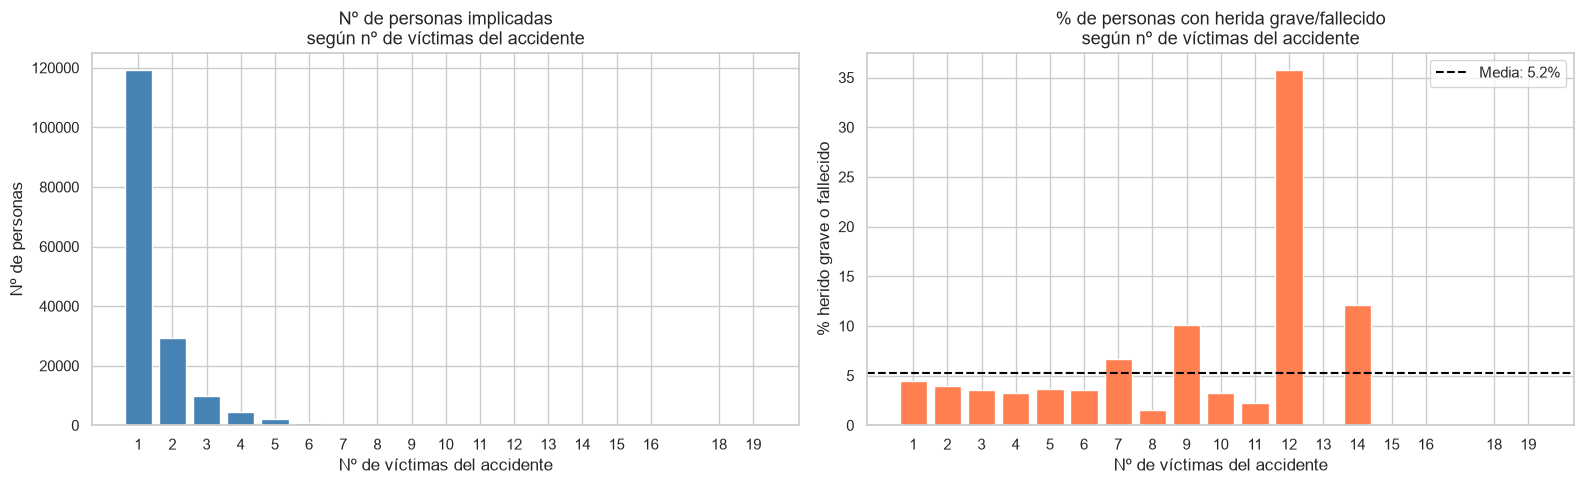

 Nº VICTIMAS *  pct_grave  n_personas
             1   4.435731      119101
             2   3.946424       29267
             3   3.576480        9898
             4   3.233256        4330
             5   3.647416        1974
             6   3.543307         762
             7   6.642729         557
             8   1.546392         194
             9  10.112360          89
            10   3.260870          92
            11   2.272727          44
            12  35.714286          28
            13   0.000000          27
            14  12.121212          33
            15   0.000000          17
            16   0.000000          19
            18   0.000000          20
            19   0.000000          41


In [90]:
# Relación entre nº de víctimas y tasa de gravedad
# Mezclamos df_sin_na (nivel persona) ya que contiene GRAVE y Nº VICTIMAS *
tasa_grave_vic = (df_sin_na.groupby('Nº VICTIMAS *')['GRAVE']
                            .agg(['mean', 'count'])
                            .rename(columns={'mean': 'pct_grave', 'count': 'n_personas'})
                            .assign(pct_grave=lambda x: x['pct_grave'] * 100)
                            .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(tasa_grave_vic['Nº VICTIMAS *'], tasa_grave_vic['n_personas'],
            color='steelblue', edgecolor='white')
axes[0].set_title('Nº de personas implicadas\nsegún nº de víctimas del accidente', fontsize=13)
axes[0].set_xlabel('Nº de víctimas del accidente'); axes[0].set_ylabel('Nº de personas')
axes[0].set_xticks(tasa_grave_vic['Nº VICTIMAS *'])

axes[1].bar(tasa_grave_vic['Nº VICTIMAS *'], tasa_grave_vic['pct_grave'],
            color='coral', edgecolor='white')
media_grave = tasa_grave_vic['pct_grave'].mean()
axes[1].axhline(media_grave, color='black', linestyle='--', label=f'Media: {media_grave:.1f}%')
axes[1].set_title('% de personas con herida grave/fallecido\nsegún nº de víctimas del accidente', fontsize=13)
axes[1].set_xlabel('Nº de víctimas del accidente'); axes[1].set_ylabel('% herido grave o fallecido')
axes[1].set_xticks(tasa_grave_vic['Nº VICTIMAS *'])
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/15b_gravedad_por_nro_victimas.png', dpi=150)
plt.show()

print(tasa_grave_vic.to_string(index=False))

### 📝 Resumen — Sección 6

> - `Nº VICTIMAS *` es la única variable numérica del dataset. Su distribución es **fuertemente asimétrica a la derecha** (skewness > 0): la gran mayoría de accidentes tienen 1 o 2 víctimas, siendo los accidentes con muchas víctimas raros pero presentes.
> - La mediana es 1 (la mitad de los accidentes tienen solo 1 víctima) y la moda también es 1, mientras que la media es ligeramente superior, confiriendo la asimetría positiva.
> - El **test KS rechaza la normalidad** de la variable (p << 0.05). Esto es relevante para técnicas paramétricas, pero no afecta a modelos basados en árboles.
> - Los outliers (accidentes con muchas víctimas, por encima del límite IQR) representan un porcentaje reducido del total, pero son precisamente los accidentes más graves.
> - Se observa una **relación positiva entre el número de víctimas y la tasa de gravedad**: a mayor número de víctimas, mayor proporción de heridos graves y fallecidos, lo que refuerza el valor predictivo de esta variable.

---
## 7. Perfil de los implicados

El perfil de las personas implicadas en el accidente (su rol, sexo, edad y tipo de vehículo) puede estar relacionado con la gravedad de las consecuencias. Se analiza también la tasa de gravedad según la franja horaria.

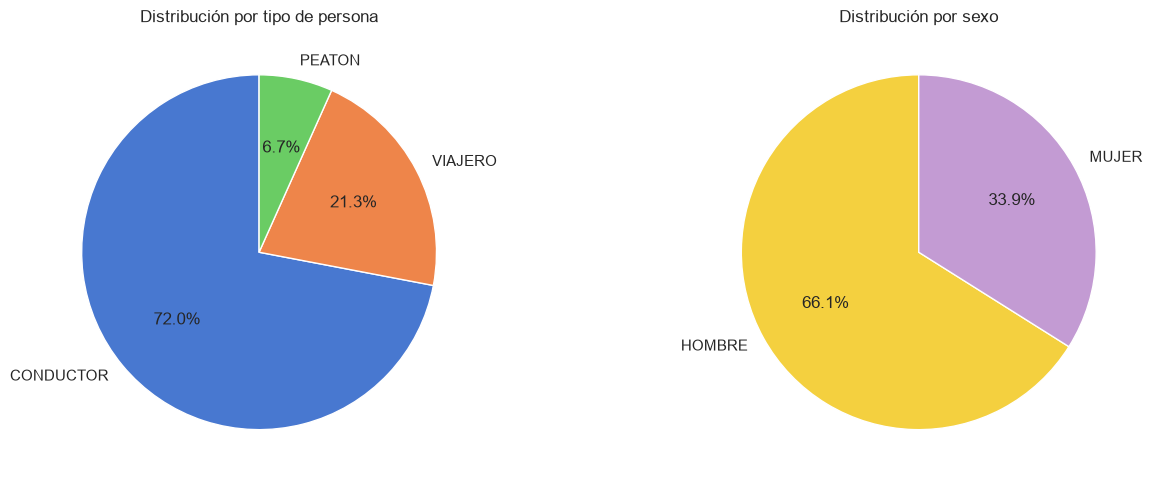

In [92]:
# Distribución por tipo de persona y sexo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tipo_persona_counts = df['TIPO PERSONA'].value_counts()
axes[0].pie(tipo_persona_counts.values, labels=tipo_persona_counts.index,
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribución por tipo de persona')

sexo_counts = df[df['SEXO'].isin(['HOMBRE', 'MUJER'])]['SEXO'].value_counts()
axes[1].pie(sexo_counts.values, labels=sexo_counts.index,
            autopct='%1.1f%%', startangle=90, colors=['#F4D03F', '#C39BD3'])
axes[1].set_title('Distribución por sexo')

plt.tight_layout()
plt.savefig('../figures/10_perfil_implicados.png', dpi=150)
plt.show()

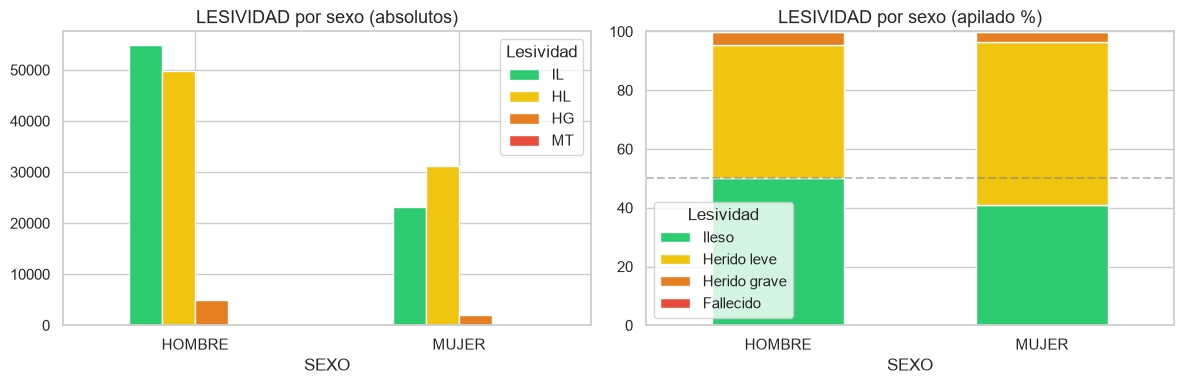

In [95]:
# LESIVIDAD por sexo
lesividad_sexo = (df_sin_na[df_sin_na['SEXO'].isin(['HOMBRE', 'MUJER'])]
                  .groupby(['SEXO', 'LESIVIDAD']).size()
                  .unstack(fill_value=0)
                  .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_sexo_pct = lesividad_sexo.div(lesividad_sexo.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lesividad_sexo.plot(kind='bar', ax=axes[0],
                    color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('LESIVIDAD por sexo (absolutos)', fontsize=13)
axes[0].tick_params(axis='x', rotation=0); axes[0].legend(title='Lesividad')

lesividad_sexo_pct.plot(kind='bar', stacked=True, ax=axes[1],
                         color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('LESIVIDAD por sexo (apilado %)', fontsize=13)
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'])

plt.tight_layout()
plt.savefig('../figures/10b_lesividad_por_sexo.png', dpi=150)
plt.show()

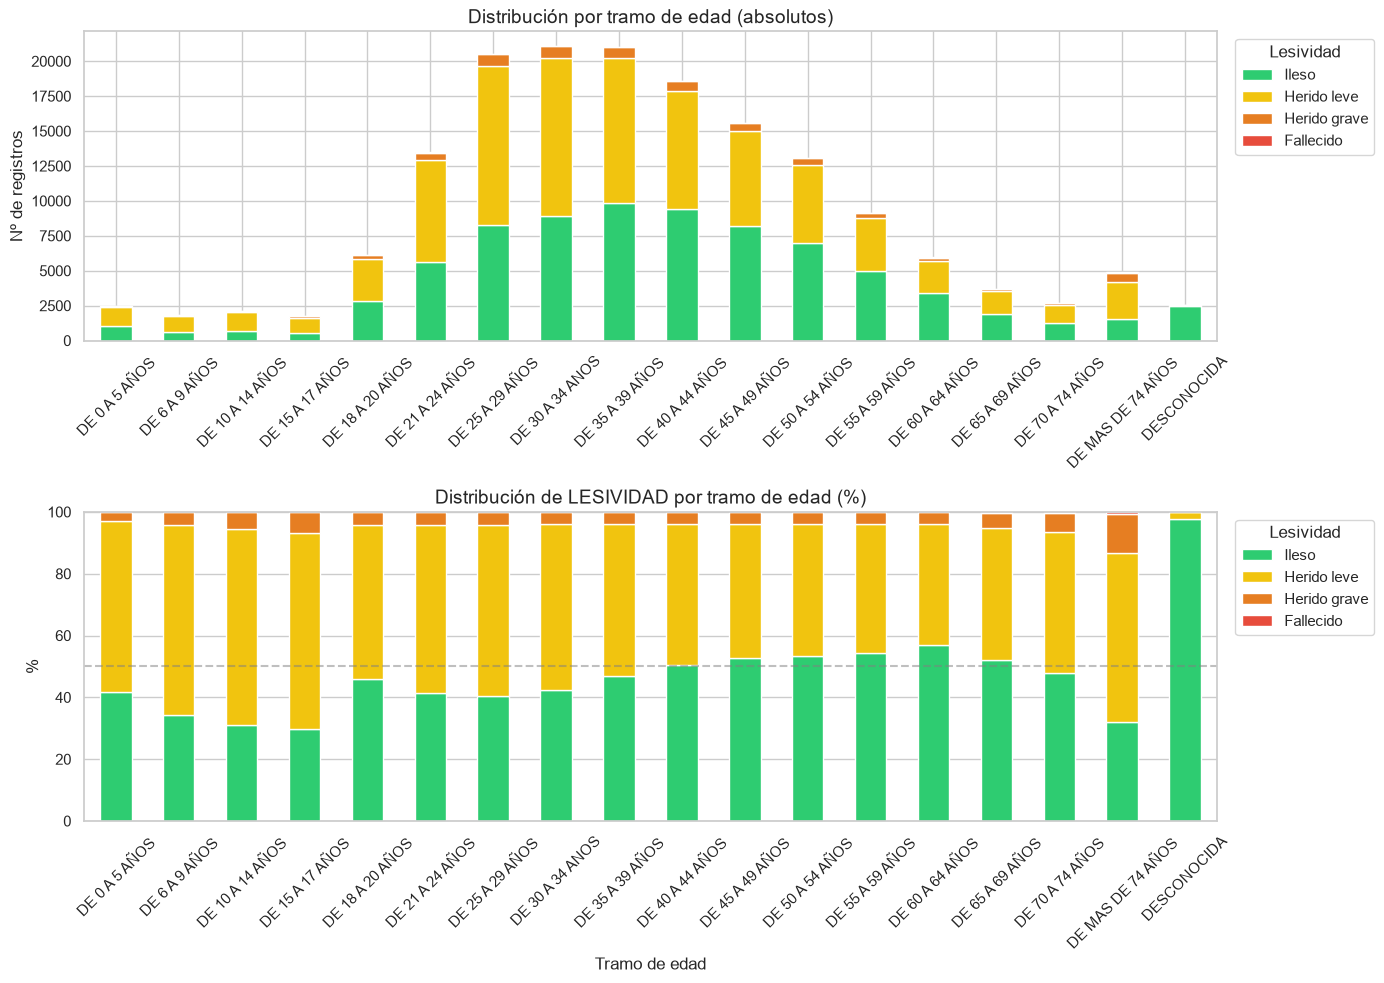

In [97]:
# Distribución por tramo de edad y LESIVIDAD
orden_edad = [
    'DE 0 A 5 AÑOS', 'DE 6 A 9 AÑOS', 'DE 10 A 14 AÑOS', 'DE 15 A 17 AÑOS',
    'DE 18 A 20 AÑOS', 'DE 21 A 24 AÑOS', 'DE 25 A 29 AÑOS', 'DE 30 A 34 ANOS',
    'DE 35 A 39 AÑOS', 'DE 40 A 44 AÑOS', 'DE 45 A 49 AÑOS', 'DE 50 A 54 AÑOS',
    'DE 55 A 59 AÑOS', 'DE 60 A 64 AÑOS', 'DE 65 A 69 AÑOS', 'DE 70 A 74 AÑOS',
    'DE MAS DE 74 AÑOS', 'DESCONOCIDA'
]

lesividad_edad = (df_sin_na.groupby(['Tramo Edad', 'LESIVIDAD'])
                           .size()
                           .unstack(fill_value=0)
                           .reindex(index=orden_edad, columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_edad_pct = lesividad_edad.div(lesividad_edad.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

lesividad_edad.plot(kind='bar', stacked=True, ax=axes[0],
                    color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('Distribución por tramo de edad (absolutos)', fontsize=14)
axes[0].set_xlabel(''); axes[0].set_ylabel('Nº de registros')
axes[0].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=45)

lesividad_edad_pct.plot(kind='bar', stacked=True, ax=axes[1],
                        color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('Distribución de LESIVIDAD por tramo de edad (%)', fontsize=14)
axes[1].set_xlabel('Tramo de edad'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/11_tramo_edad.png', dpi=150, bbox_inches='tight')
plt.show()

Distribución de LESIVIDAD por tipo de persona (%):
LESIVIDAD       IL    HL    HG   MT
TIPO PERSONA                       
CONDUCTOR     51.9  44.6   3.4  0.1
PEATON         2.1  78.0  19.0  0.9
VIAJERO       46.3  51.8   1.9  0.0


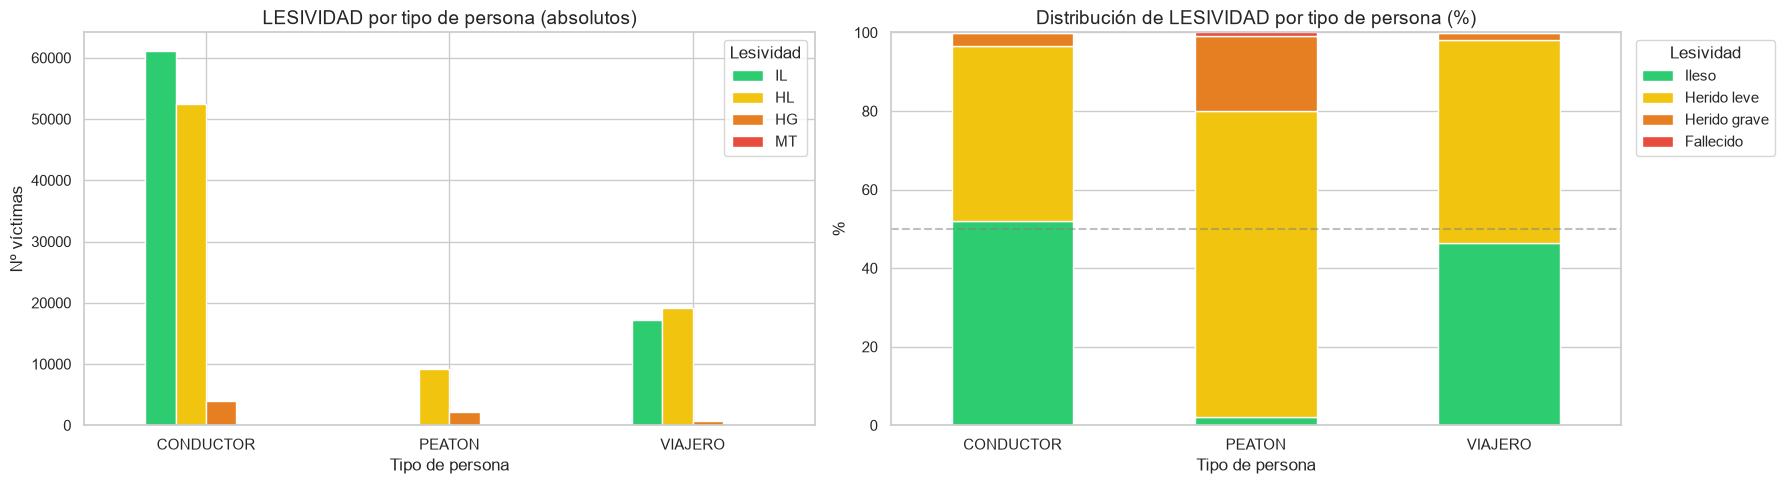

In [100]:
# LESIVIDAD por tipo de persona
lesividad_tipo = (df_sin_na.groupby(['TIPO PERSONA', 'LESIVIDAD'])
                            .size()
                            .unstack(fill_value=0)
                            .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_tipo_pct = lesividad_tipo.div(lesividad_tipo.sum(axis=1), axis=0) * 100

print('Distribución de LESIVIDAD por tipo de persona (%):')
print(lesividad_tipo_pct.round(1))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

lesividad_tipo.plot(kind='bar', ax=axes[0],
                    color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[0].set_title('LESIVIDAD por tipo de persona (absolutos)', fontsize=14)
axes[0].set_xlabel('Tipo de persona'); axes[0].set_ylabel('Nº víctimas')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Lesividad')

lesividad_tipo_pct.plot(kind='bar', stacked=True, ax=axes[1],
                        color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD], edgecolor='white')
axes[1].set_title('Distribución de LESIVIDAD por tipo de persona (%)', fontsize=14)
axes[1].set_xlabel('Tipo de persona'); axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].axhline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../figures/10c_lesividad_por_tipo_persona.png', dpi=150, bbox_inches='tight')
plt.show()

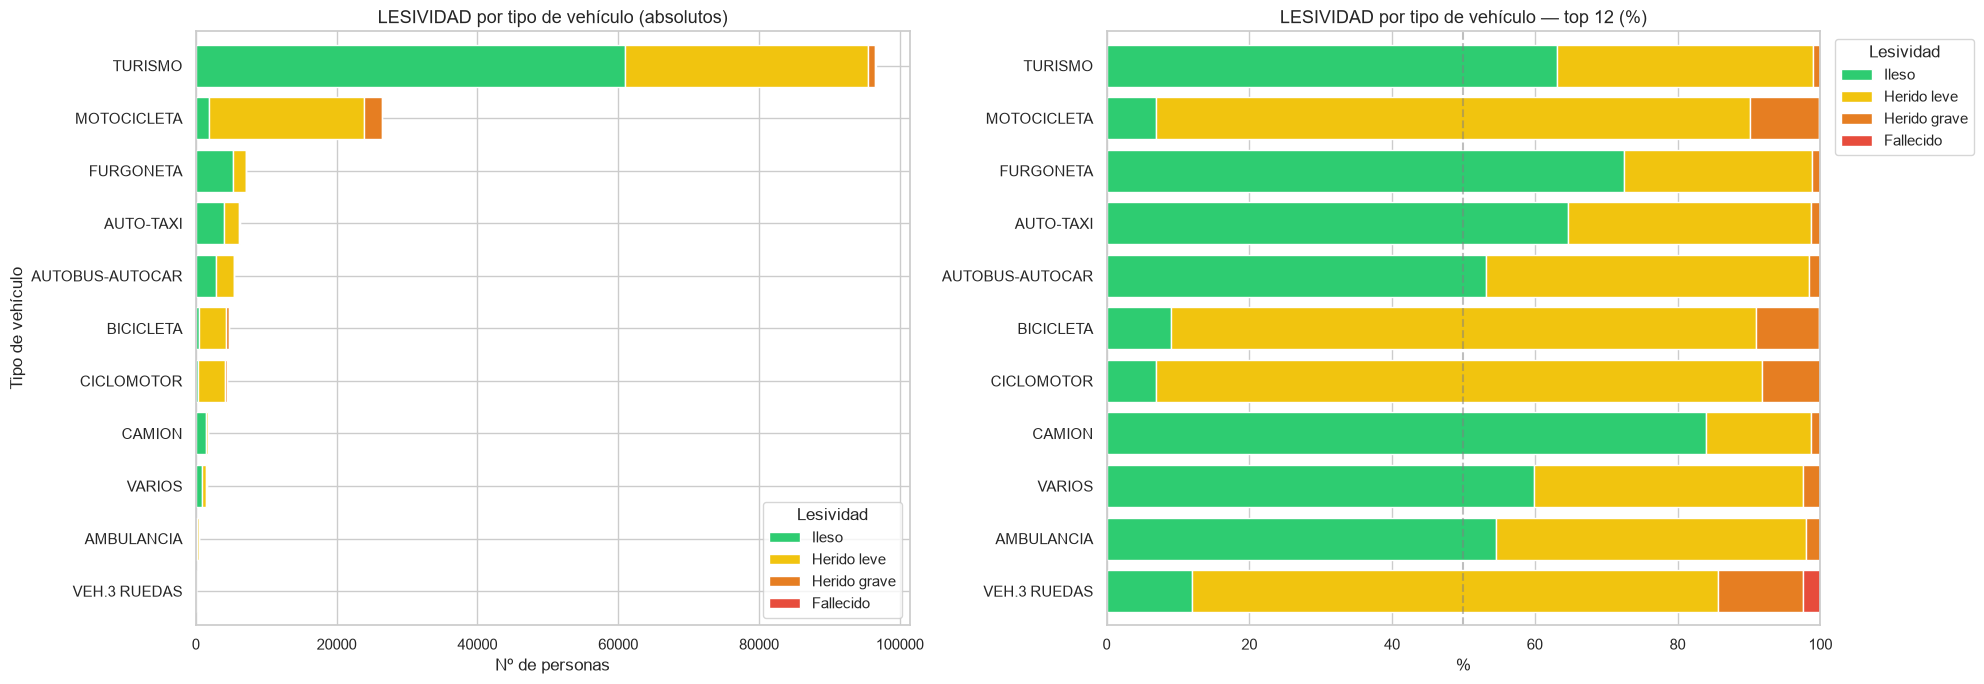

In [104]:
# --- Datos compartidos ---
df_veh_all = df_sin_na[df_sin_na['Tipo Vehiculo'] != 'NO ASIGNADO']

# Absolutos apilados por lesividad (todos los vehículos)
lesividad_veh_abs = (df_veh_all.groupby(['Tipo Vehiculo', 'LESIVIDAD'])
                                .size().unstack(fill_value=0)
                                .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_veh_abs['TOTAL'] = lesividad_veh_abs.sum(axis=1)
lesividad_veh_abs = lesividad_veh_abs.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')

# % top 12
top_vehiculos = df_veh_all['Tipo Vehiculo'].value_counts().head(12).index
lesividad_vehiculo = (df_veh_all[df_sin_na['Tipo Vehiculo'].isin(top_vehiculos)]
                      .groupby(['Tipo Vehiculo', 'LESIVIDAD'])
                      .size().unstack(fill_value=0)
                      .reindex(columns=ORDEN_LESIVIDAD, fill_value=0))
lesividad_vehiculo['TOTAL'] = lesividad_vehiculo.sum(axis=1)
lesividad_vehiculo = lesividad_vehiculo.sort_values('TOTAL', ascending=True).drop(columns='TOTAL')
lesividad_vehiculo_pct = lesividad_vehiculo.div(lesividad_vehiculo.sum(axis=1), axis=0) * 100

# --- Figura ---
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

lesividad_veh_abs.plot(kind='barh', stacked=True, ax=axes[0],
                       color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD],
                       width=0.8, edgecolor='white')
axes[0].set_title('LESIVIDAD por tipo de vehículo (absolutos)', fontsize=13)
axes[0].set_xlabel('Nº de personas'); axes[0].set_ylabel('Tipo de vehículo')
axes[0].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'])

lesividad_vehiculo_pct.plot(kind='barh', stacked=True, ax=axes[1],
                            color=[COLORES_LESIVIDAD[c] for c in ORDEN_LESIVIDAD],
                            width=0.8, edgecolor='white')
axes[1].set_title('LESIVIDAD por tipo de vehículo — top 12 (%)', fontsize=13)
axes[1].set_xlabel('%'); axes[1].set_xlim(0, 100); axes[1].set_ylabel('')
axes[1].axvline(50, color='grey', linestyle='--', alpha=0.5, label='_nolegend_')
axes[1].legend(title='Lesividad', labels=['Ileso', 'Herido leve', 'Herido grave', 'Fallecido'],
               bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/13_lesividad_por_vehiculo.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Gráfico dual: volumen de accidentes y tasa de gravedad por franja horaria
df_hora = df_sin_na.copy()
df_hora['HORA'] = df_hora['RANGO HORARIO'].str.extract(r'(\d+)').astype(float)

tasa_grave_hora  = df_hora.groupby('HORA')['GRAVE'].mean() * 100
accidentes_hora_n = df_hora.groupby('HORA').size()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(accidentes_hora_n.index, accidentes_hora_n.values, color='steelblue', alpha=0.5, label='Nº personas')
ax2.plot(tasa_grave_hora.index, tasa_grave_hora.values, color='#e74c3c',
         marker='o', linewidth=2, label='% graves')

ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Nº de registros', color='steelblue')
ax2.set_ylabel('% heridos graves o fallecidos', color='#e74c3c')
ax1.set_title('Volumen de accidentes y tasa de gravedad por franja horaria', fontsize=14)
ax1.set_xticks(range(0, 24))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../figures/14_gravedad_por_hora.png', dpi=150)
plt.show()

### 📝 Resumen — Sección 7

> - El tipo de persona más frecuente son los **conductores**, seguidos de viajeros y peatones. Los **peatones presentan la mayor proporción de heridos graves y fallecidos**, lo que los convierte en el grupo más vulnerable.
> - Los **hombres** representan un mayor volumen de accidentalidad que las mujeres. En términos de gravedad relativa, ambos sexos presentan proporciones similares, aunque los hombres muestran una tasa de HG+MT ligeramente superior.
> - Los tramos de edad con mayor gravedad relativa son los **mayores de 65 años** y los **menores de 18 años**, reflejando mayor vulnerabilidad física en edades extremas. Los tramos de 25-44 años concentran el mayor volumen de accidentes por ser los conductores más activos.
> - Los vehículos con mayor tasa de lesividad grave son las **motocicletas**, seguidas de ciclomotores y bicicletas, por la menor protección que ofrecen frente a colisiones.
> - Los **accidentes nocturnos (0h-6h)** presentan una tasa de gravedad significativamente superior a la media, aunque son menos frecuentes. Esto podría deberse a mayor velocidad, menor visibilidad o conducción bajo efectos del alcohol.

---
## 8. Análisis multivariante y asociación estadística

En esta sección se estudian las relaciones entre variables categóricas clave y la variable objetivo `GRAVE` mediante:
1. **V de Cramér**: medida de asociación entre variables categóricas (análogo al coeficiente de correlación para categóricas), con valores entre 0 (sin asociación) y 1 (asociación perfecta).
2. **Test chi-cuadrado**: contraste de independencia entre cada variable predictora y la variable objetivo.

Estos análisis permiten identificar qué variables tienen mayor potencial predictivo antes de construir el modelo.

In [106]:
# Función para calcular la V de Cramér
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    if denom <= 0:
        return 0.0
    return np.sqrt(phi2corr / denom)

# Variables categóricas clave (excluir identificadores y fecha)
vars_categoricas = ['TIPO ACCIDENTE', 'DIA SEMANA', 'RANGO HORARIO', 'DISTRITO',
                    'TIPO PERSONA', 'SEXO', 'Tramo Edad', 'Tipo Vehiculo', 'LUGAR ACCIDENTE']

# Filtrar a las que existen en df_sin_na
vars_categoricas = [v for v in vars_categoricas if v in df_sin_na.columns]

# Calcular V de Cramér de cada variable con LESIVIDAD y con GRAVE
print('V de Cramér con la variable objetivo:')
print(f'{"Variable":<25} {"V Cramér vs LESIVIDAD":>22} {"V Cramér vs GRAVE":>20}')
print('-' * 70)

resultados = []
for var in vars_categoricas:
    mask = df_sin_na[var].notna() & df_sin_na['LESIVIDAD'].notna()
    v_les = cramers_v(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'LESIVIDAD'])
    v_gra = cramers_v(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'GRAVE'].astype(str))
    resultados.append({'Variable': var, 'V_Lesividad': v_les, 'V_Grave': v_gra})
    print(f'{var:<25} {v_les:>22.4f} {v_gra:>20.4f}')

df_cramer = pd.DataFrame(resultados).sort_values('V_Grave', ascending=False)

V de Cramér con la variable objetivo:
Variable                   V Cramér vs LESIVIDAD    V Cramér vs GRAVE
----------------------------------------------------------------------
TIPO ACCIDENTE                            0.1388               0.1362
DIA SEMANA                                0.0079               0.0117
RANGO HORARIO                             0.0367               0.0503
DISTRITO                                  0.0144               0.0122
TIPO PERSONA                              0.2167               0.2154
SEXO                                      0.0802               0.0242
Tramo Edad                                0.1118               0.0859
Tipo Vehiculo                             0.3219               0.2721
LUGAR ACCIDENTE                           0.0630               0.1918


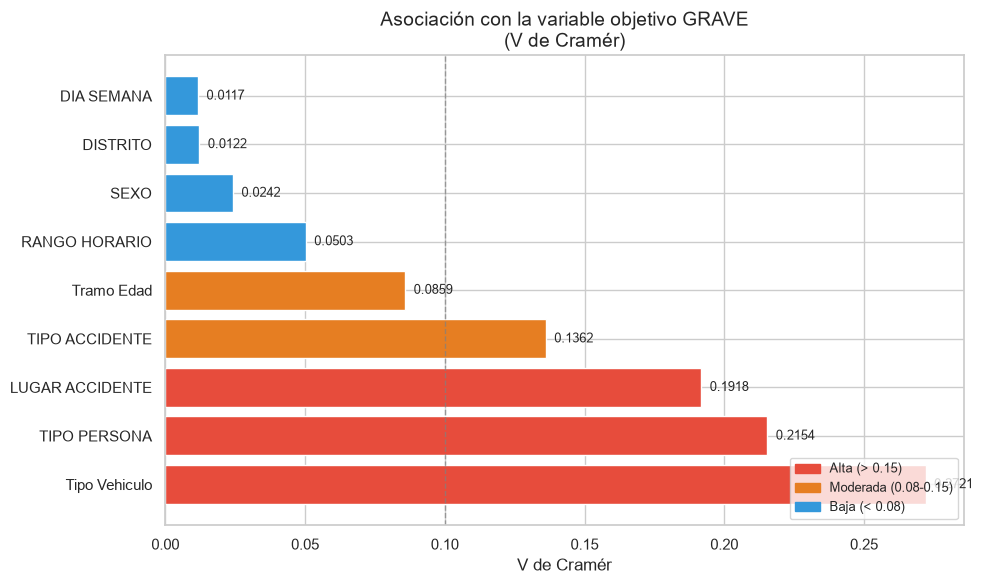

In [107]:
# Visualización: ranking de V de Cramér con GRAVE
fig, ax = plt.subplots(figsize=(10, 6))

colores_cv = ['#e74c3c' if v > 0.15 else '#e67e22' if v > 0.08 else '#3498db'
              for v in df_cramer['V_Grave']]
bars = ax.barh(df_cramer['Variable'], df_cramer['V_Grave'], color=colores_cv)

for bar, val in zip(bars, df_cramer['V_Grave']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.axvline(0.10, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Umbral moderado (0.10)')
ax.set_title('Asociación con la variable objetivo GRAVE\n(V de Cramér)', fontsize=14)
ax.set_xlabel('V de Cramér')
ax.legend()

from matplotlib.patches import Patch
leyenda = [Patch(color='#e74c3c', label='Alta (> 0.15)'),
           Patch(color='#e67e22', label='Moderada (0.08-0.15)'),
           Patch(color='#3498db', label='Baja (< 0.08)')]
ax.legend(handles=leyenda, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/16_cramer_v_asociacion.png', dpi=150, bbox_inches='tight')
plt.show()

In [108]:
# Tests chi-cuadrado: independencia entre cada variable y GRAVE
print(f'Test chi-cuadrado (H0: independencia entre variable y GRAVE)')
print(f'{"Variable":<25} {"chi2":>12} {"p-valor":>15} {"Sig.":>6}')
print('-' * 65)

for _, row in df_cramer.iterrows():
    var = row['Variable']
    mask = df_sin_na[var].notna() & df_sin_na['GRAVE'].notna()
    ct = pd.crosstab(df_sin_na.loc[mask, var], df_sin_na.loc[mask, 'GRAVE'])
    chi2_val, p_val, _, _ = chi2_contingency(ct)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    print(f'{var:<25} {chi2_val:>12.1f} {p_val:>15.2e} {sig:>6}')

print('\nSignificancia: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = no significativo')

Test chi-cuadrado (H0: independencia entre variable y GRAVE)
Variable                          chi2         p-valor   Sig.
-----------------------------------------------------------------
Tipo Vehiculo                  12336.3        0.00e+00    ***
TIPO PERSONA                    7729.7        0.00e+00    ***
LUGAR ACCIDENTE                20082.3       4.94e-230    ***
TIPO ACCIDENTE                  3096.7        0.00e+00    ***
Tramo Edad                      1244.7       3.47e-254    ***
RANGO HORARIO                    443.9        1.55e-79    ***
SEXO                              99.8        2.12e-22    ***
DISTRITO                          44.9        1.16e-03     **
DIA SEMANA                        28.9        6.45e-05    ***

Significancia: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = no significativo


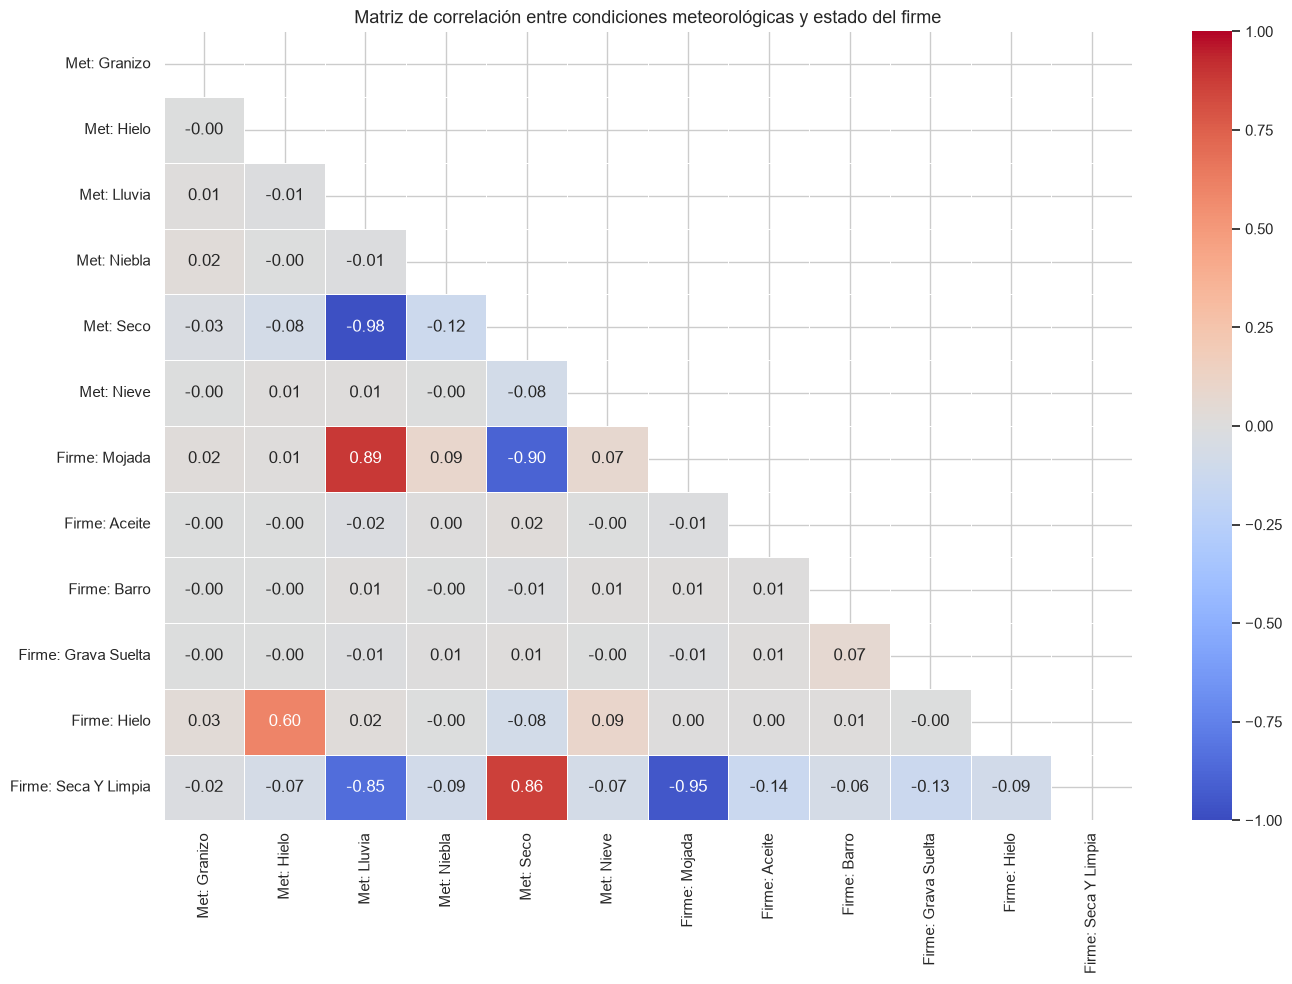

In [109]:
# Heatmap de co-ocurrencia entre condiciones CPFA y CPSV (nivel accidente)
cols_cond = [c for c in df_acc.columns if c.startswith('CPFA') or c.startswith('CPSV')]

# Convertir a binario
cond_binary = df_acc[cols_cond].apply(lambda x: x.str.strip()).replace({'SI': 1, 'NO': 0})
cond_binary.columns = [c.replace('CPFA ', 'Met: ').replace('CPSV ', 'Firme: ') for c in cond_binary.columns]

corr_cond = cond_binary.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask_tri = np.triu(np.ones_like(corr_cond, dtype=bool))
sns.heatmap(corr_cond, mask=mask_tri, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación entre condiciones meteorológicas y estado del firme', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/17_heatmap_condiciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 📝 Resumen — Sección 8

> - La **V de Cramér** confirma que la variable con mayor asociación con la gravedad del accidente es `TIPO PERSONA`, seguida de `Tipo Vehiculo` y `Tramo Edad`. Esto es coherente con los hallazgos de la sección anterior: el perfil de la víctima es determinante en la gravedad.
> - `TIPO ACCIDENTE` y `LUGAR ACCIDENTE` también muestran una asociación moderada, confirmando su potencial predictivo.
> - Variables temporales como `DIA SEMANA` y `RANGO HORARIO` presentan asociaciones más bajas, aunque estadísticamente significativas (test chi-cuadrado con p << 0.001).
> - **Todas las variables analizadas resultan estadísticamente significativas** respecto a la variable objetivo según el test chi-cuadrado. Esto sugiere que ninguna debería descartarse a priori, aunque la fuerza de la asociación varía considerablemente.
> - El heatmap de condiciones meteorológicas y estado del firme muestra correlaciones esperables (ej. lluvia y firme mojado), lo que podría justificar combinar algunas de estas variables binarias en índices compuestos durante el preprocesado.

---
## 9. Conclusiones del EDA

En esta sección se recogen los hallazgos más relevantes del análisis exploratorio y se extraen las implicaciones para la fase de preprocesado y modelización.

### Variables más prometedoras para el modelo

| Variable | Tipo | V Cramér (aprox.) | Observación |
|----------|------|-------------------|-------------|
| `TIPO PERSONA` | Categórica | Alta | Los peatones presentan la mayor tasa de HG+MT |
| `Tipo Vehiculo` | Categórica | Alta | Motocicletas y bicicletas con mayor gravedad |
| `Tramo Edad` | Categórica | Moderada | Mayores de 65 y menores de 18 más vulnerables |
| `TIPO ACCIDENTE` | Categórica | Moderada | Alta variabilidad en gravedad según tipo |
| `LUGAR ACCIDENTE` | Categórica | Moderada | Vías de alta velocidad vs. intersecciones |
| `RANGO HORARIO` | Categórica | Baja-moderada | Accidentes nocturnos con mayor tasa de gravedad |
| `DISTRITO` | Categórica | Baja-moderada | Heterogeneidad geográfica en tasa de gravedad |
| `DIA SEMANA` | Categórica | Baja | Diferencias entre laborables y fin de semana |
| `CPFA_*` | Binaria | Baja | Condiciones adversas relacionadas con gravedad |
| `CPSV_*` | Binaria | Baja | Estado del firme relacionado con la gravedad |
| `Nº VICTIMAS *` | Numérica | — | A mayor nº víctimas, mayor probabilidad de gravedad |

### Decisiones tomadas para la fase de preprocesado

> 1. La variable objetivo se construirá como la **LESIVIDAD máxima por accidente** (`Nº PARTE`)
> 2. Los testigos ya han sido excluidos en este notebook
> 3. Se eliminarán las **4.065 filas duplicadas exactas** (errores de registro)
> 4. Se eliminarán los **7.860 registros con `LESIVIDAD = 'NO ASIGNADA'`**
> 5. Se usará **clasificación binaria**: Leve/Sin heridos vs. Grave/Fallecido
> 6. El dataset presenta un **desequilibrio de clases severo (~4% graves, ratio ~22:1)**: se abordará con `class_weight='balanced'`, SMOTE o umbral de clasificación ajustado en la fase de modelización
> 7. La variable numérica `Nº VICTIMAS *` presenta **distribución no normal y asimétrica**: se evaluará su transformación logarítmica o de raíz cuadrada
> 8. Las variables `CPFA_*` y `CPSV_*` ya son binarias y no requieren codificación adicional
> 9. Las variables categóricas nominales requerirán **codificación ordinal o one-hot** según el modelo elegido

In [ ]:
# Resumen final del EDA
print('=== RESUMEN DEL EDA ===')
print(f'Total registros (sin testigos):   {len(df):>10,}')
print(f'Total accidentes únicos:          {df["Nº PARTE"].nunique():>10,}')
print(f'Período:                          {df["FECHA"].min().date()} — {df["FECHA"].max().date()}')
print(f'\nDistribución de LESIVIDAD (nivel persona):')
print(df['LESIVIDAD'].value_counts(normalize=True).mul(100).round(2).to_string())
pct_graves = df['LESIVIDAD'].isin(['HG','MT']).mean()*100
print(f'\nDesequilibrio de clases (HG+MT vs resto): {pct_graves:.2f}% graves')
print(f'Ratio aproximado: {100/pct_graves:.0f}:1')